# 1. Importação de Bibliotecas


In [90]:

# ============================================
# Imports utilizados ao longo de todo o projeto
# ============================================


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler


from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

from sklearn.model_selection import ParameterGrid

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance


from imblearn.over_sampling import SMOTE


from scipy.stats import iqr, zscore


from math import sqrt
import warnings

warnings.filterwarnings("ignore")



# 2. Carregamento e Inspeção Inicial dos Dados

## 2.1 Carregar Dataset

In [91]:
wine_data = pd.read_csv('wine_quality.csv')

## 2.2 Visualização Inicial (`head`)

In [92]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2.3 Estatísticas Descritivas (`describe`)

In [93]:
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 2.4 Estrutura e Tipos de Dados (`info`)

In [94]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 2.5 Distribuição da Variável `quality`

In [95]:
wine_data['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

# 3. Análise Exploratória dos Dados (EDA)

## 3.1 Distribuição das Classes de Qualidade

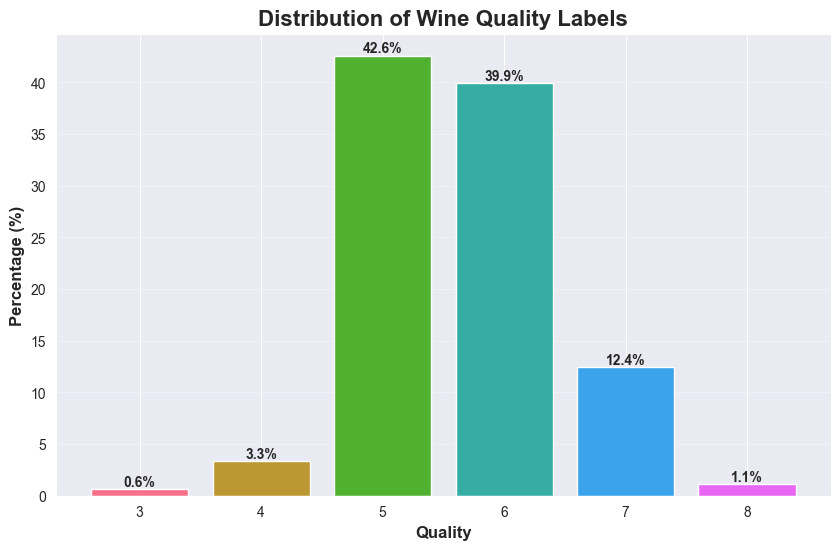

In [96]:
quality_counts = wine_data['quality'].value_counts().sort_index()

quality_percentages = (quality_counts / quality_counts.sum()) * 100

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(quality_percentages.index, quality_percentages.values,
               color=sns.color_palette('husl', len(quality_percentages)))

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontweight='bold')

plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Distribution of Wine Quality Labels', fontsize=16, fontweight='bold')
plt.xticks(quality_percentages.index)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 3.2 Análise Univariada das Features

- Fixed acidity

<Axes: xlabel='quality', ylabel='fixed acidity'>

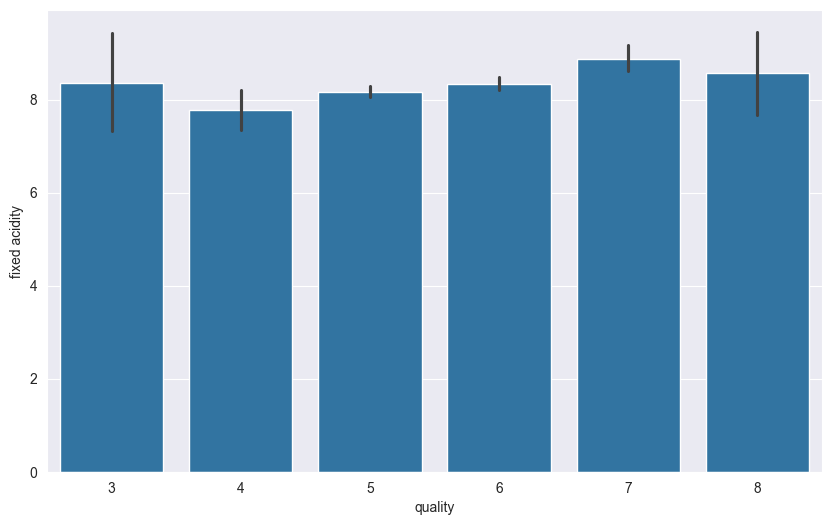

In [97]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'fixed acidity', data = wine_data)


`Fixed acity does not give any specification to classify the quality`

- Volatile acidity

<Axes: xlabel='quality', ylabel='volatile acidity'>

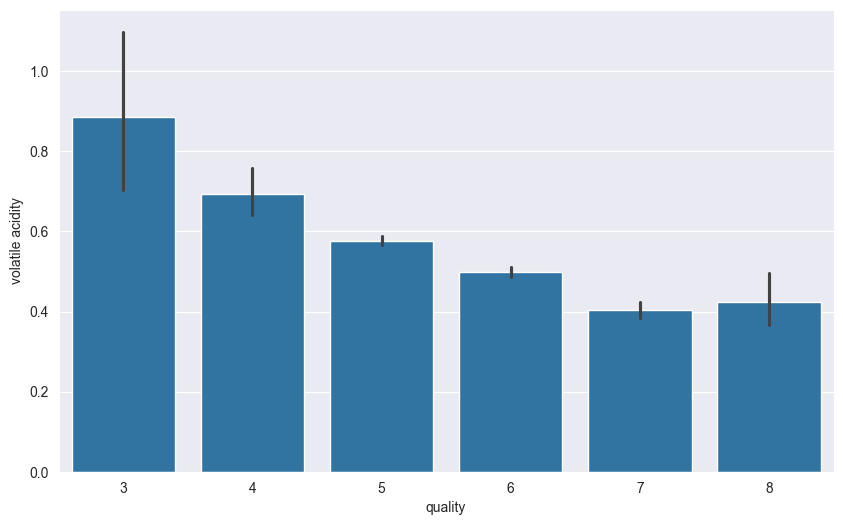

In [98]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine_data)


`Quite a downing trend in the volatile acidy as we go higher the quality`

- Citric acid

<Axes: xlabel='quality', ylabel='citric acid'>

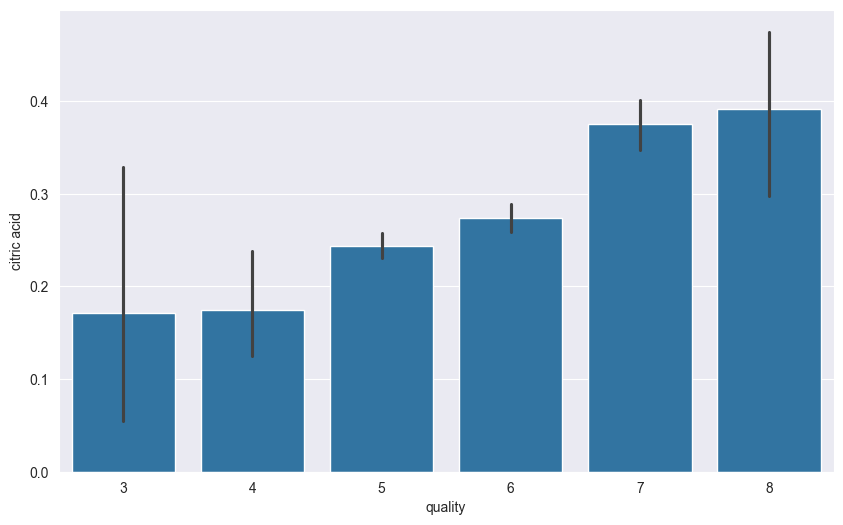

In [99]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'citric acid', data = wine_data)


`Citric acid go higher as we go higher in the quality of the wine`

- Residual sugar

<Axes: xlabel='quality', ylabel='residual sugar'>

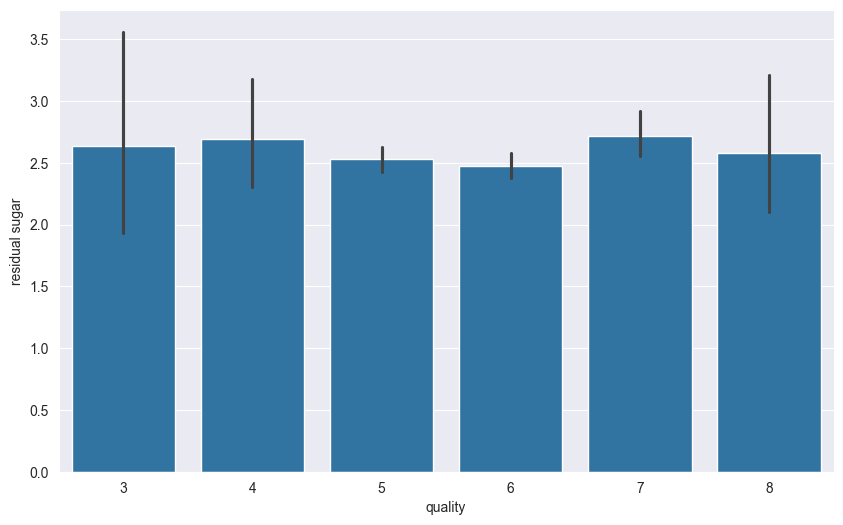

In [100]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'residual sugar', data = wine_data)


`Residual sugar does not give any specification to classify the quality`

- Chlorides

<Axes: xlabel='quality', ylabel='chlorides'>

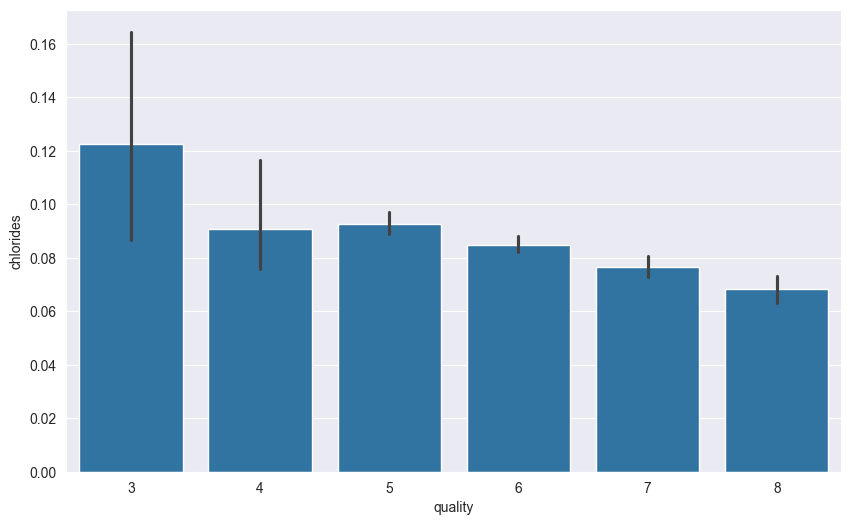

In [101]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'chlorides', data = wine_data)


`Composition of chloride also go down as we go higher in the quality of the wine`

- Free sulfur dioxide

<Axes: xlabel='quality', ylabel='free sulfur dioxide'>

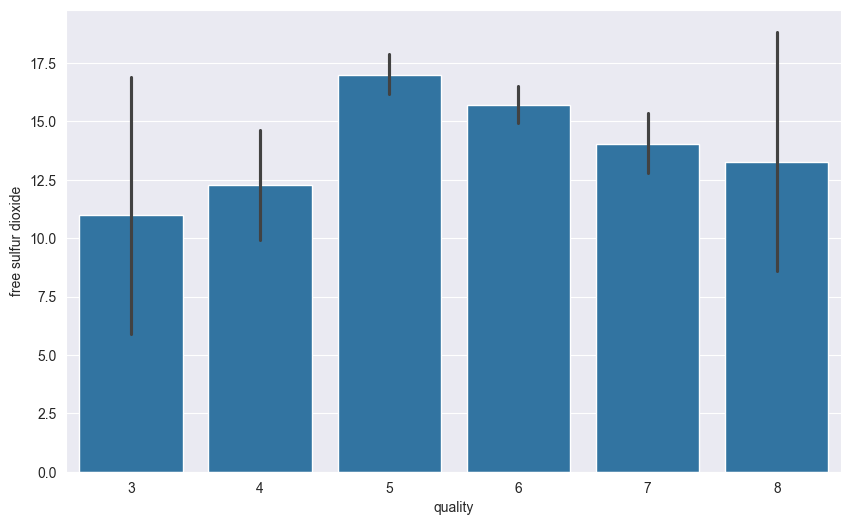

In [102]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'free sulfur dioxide', data = wine_data)


- Total sulfur dioxide

<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

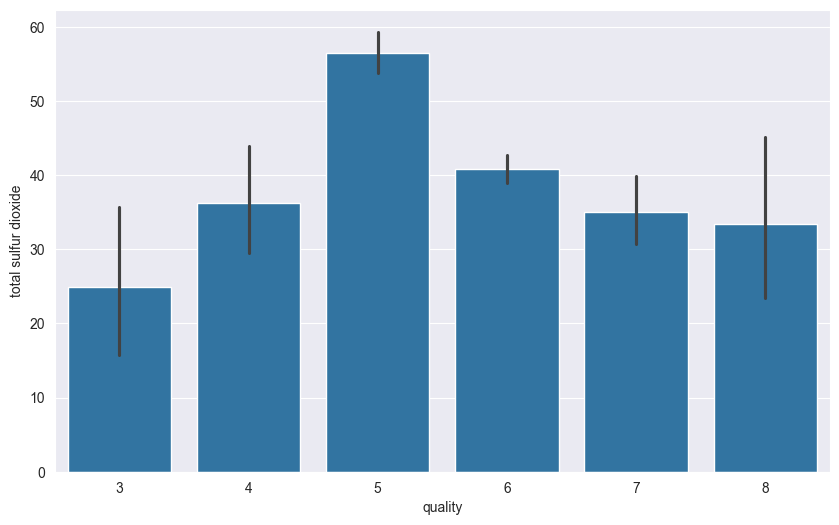

In [103]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'total sulfur dioxide', data = wine_data)


- Density

<Axes: xlabel='quality', ylabel='density'>

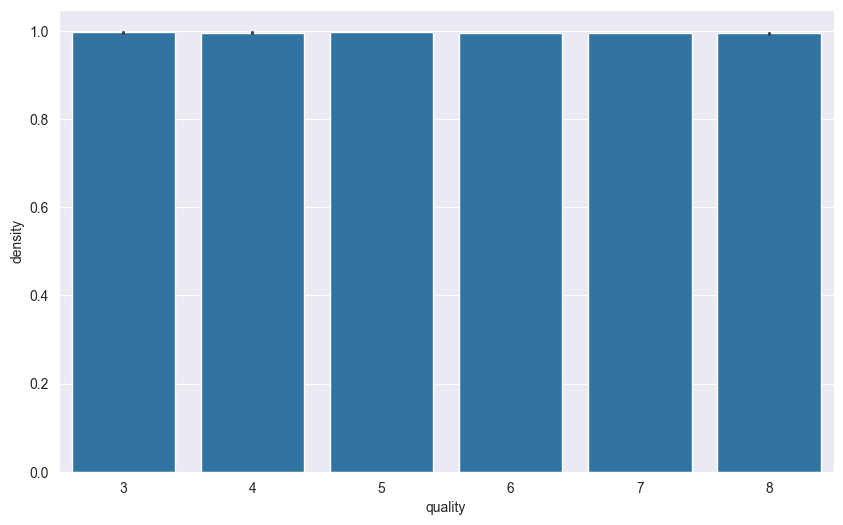

In [104]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'density', data = wine_data)


- pH

<Axes: xlabel='quality', ylabel='pH'>

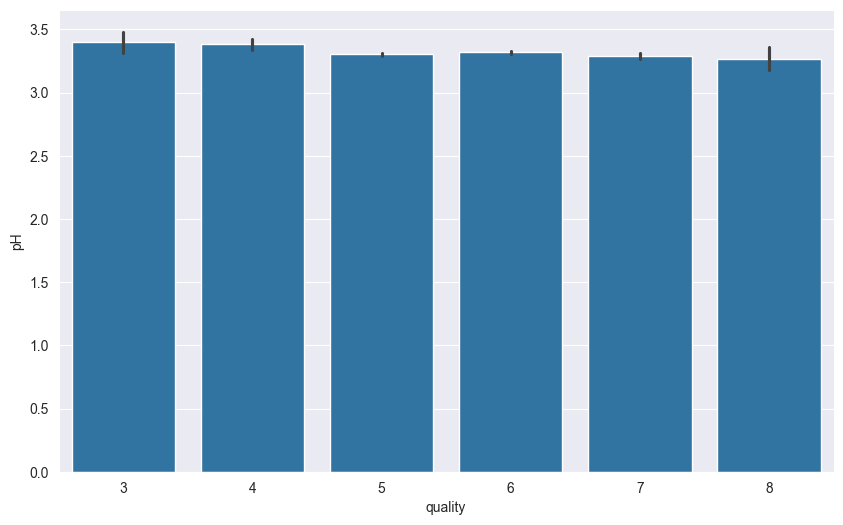

In [105]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'pH', data = wine_data)


- Sulphates

<Axes: xlabel='quality', ylabel='sulphates'>

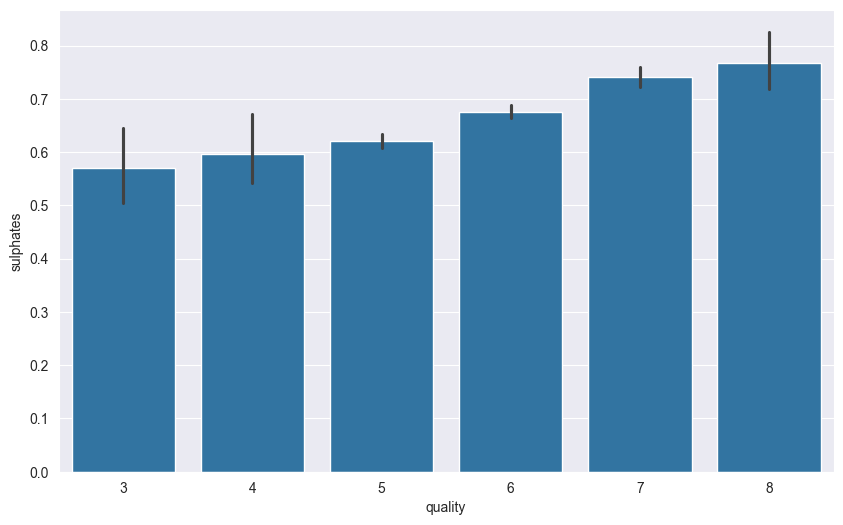

In [106]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'sulphates', data = wine_data)


`Sulphates level goes higher with the quality of wine`

- alcohol

<Axes: xlabel='quality', ylabel='alcohol'>

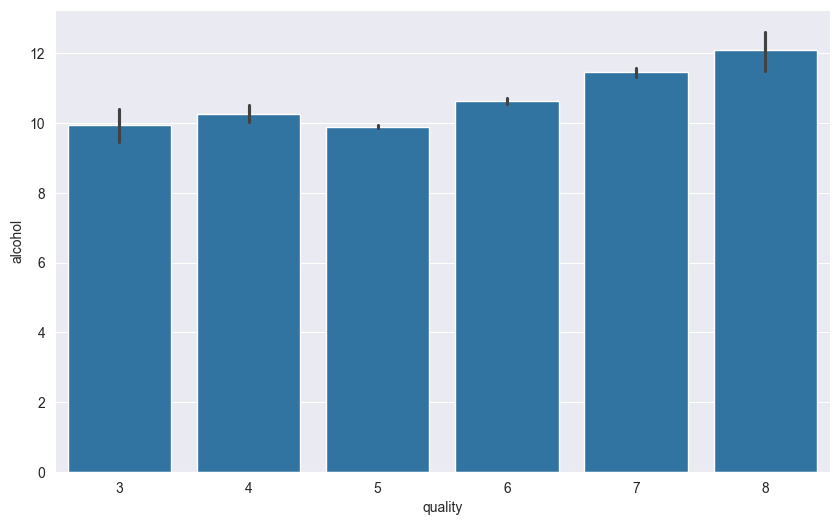

In [107]:
fig = plt.figure(figsize = (10,6))
sns.barplot(x = 'quality', y = 'alcohol', data = wine_data)


`Alcohol level also goes higher as te quality of wine increases`

## 3.3 Duplicados e missing values

In [108]:
print("Missing values por coluna:\n")
print(wine_data.isna().sum())

print("\nTotal de missing values no dataset:", wine_data.isna().sum().sum())

print("\nTotal de linhas duplicadas:")
print(wine_data.duplicated().sum())

#apagar duplicados
wine_data = wine_data.drop_duplicates()


Missing values por coluna:

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de missing values no dataset: 0

Total de linhas duplicadas:
240


## 3.4 Outliers

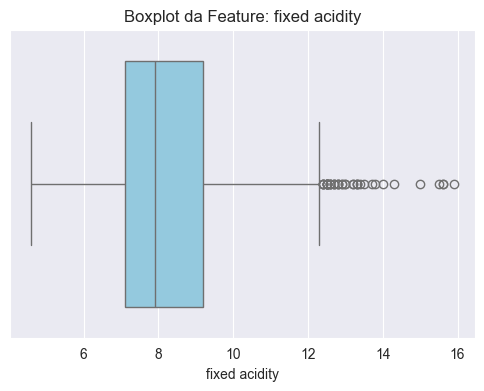

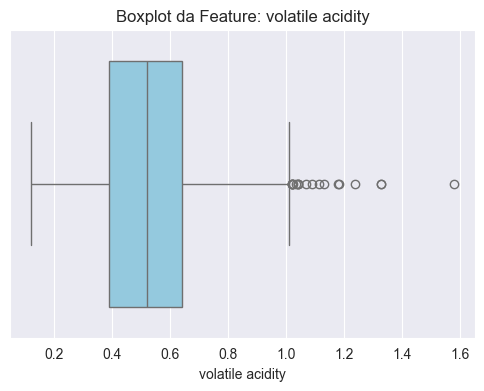

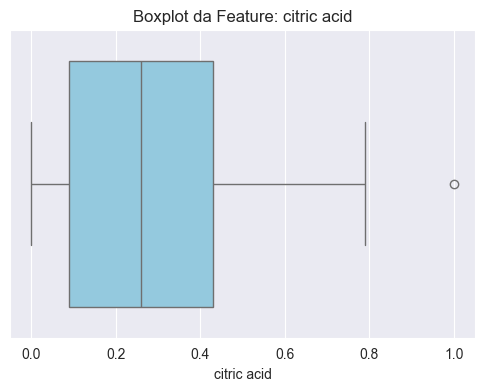

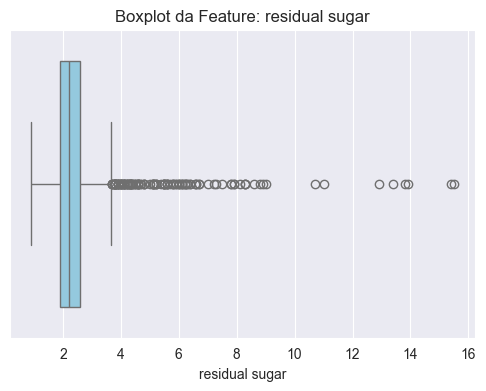

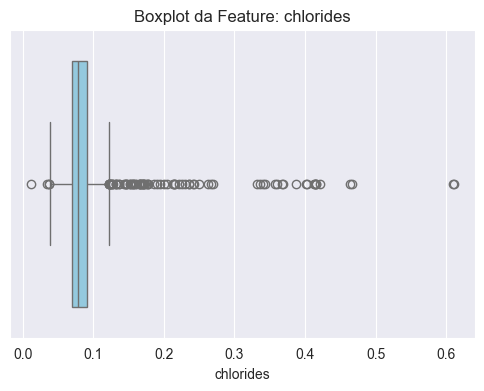

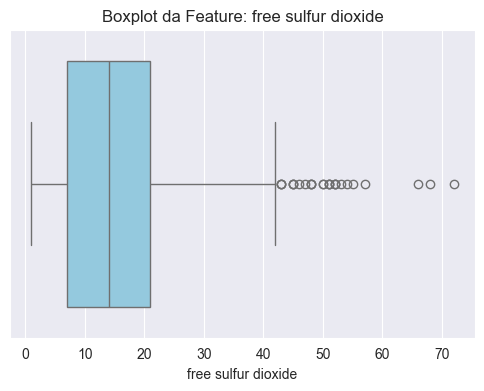

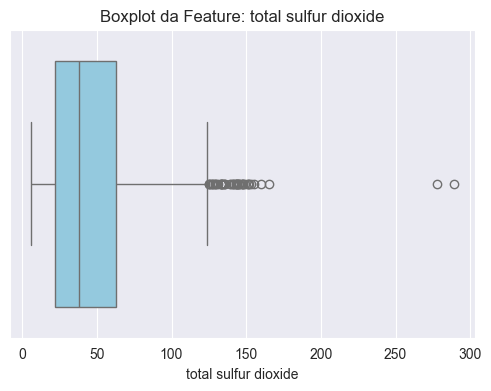

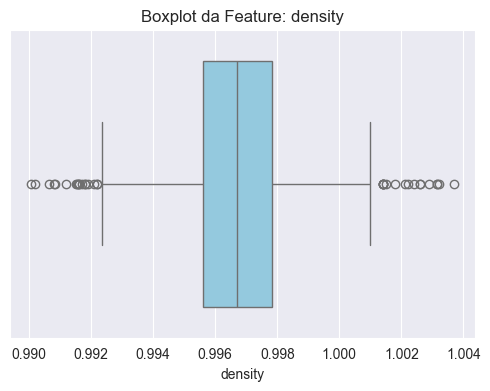

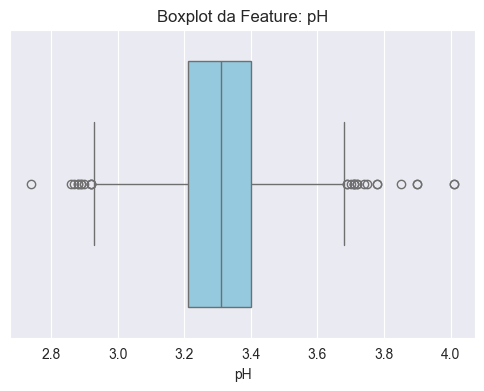

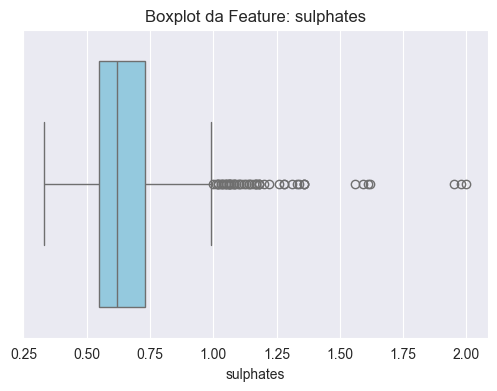

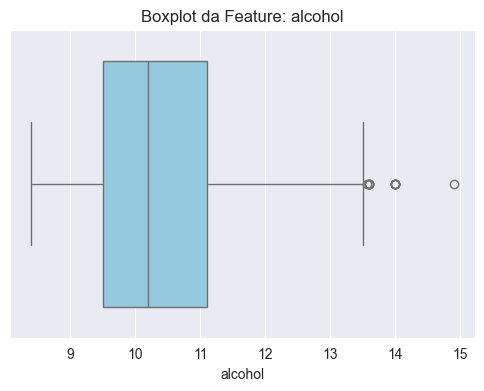

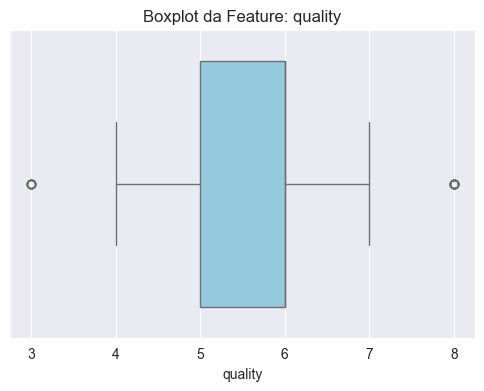

In [109]:

for col in wine_data.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=wine_data[col], color='skyblue')
    plt.title(f"Boxplot da Feature: {col}")
    plt.xlabel(col)
    plt.show()



In [110]:


outlier_summary = []

for col in wine_data.columns:
    if wine_data[col].dtype != 'object':  # só colunas numéricas

        Q1 = wine_data[col].quantile(0.25)
        Q3 = wine_data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # mascara para outliers
        outliers = wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]
        num_outliers = outliers.shape[0]
        total = wine_data.shape[0]
        perc_outliers = (num_outliers / total) * 100

        outlier_summary.append([col, num_outliers, total, perc_outliers])

# Criar DataFrame final
outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Feature", "Nº Outliers", "Total", "Percentagem (%)"])

# Ordenar da variável com mais outliers para a com menos
outlier_df = outlier_df.sort_values(by="Percentagem (%)", ascending=False)

outlier_df


,Feature,Nº Outliers,Total,Percentagem (%)
3,residual sugar,126,1359,9.271523
4,chlorides,87,1359,6.401766
9,sulphates,55,1359,4.047093
6,total sulfur dioxide,45,1359,3.311258
0,fixed acidity,41,1359,3.016924
7,density,35,1359,2.575423
8,pH,28,1359,2.060338
11,quality,27,1359,1.986755
5,free sulfur dioxide,26,1359,1.913171
1,volatile acidity,19,1359,1.398087


## 3.5 Distribuições

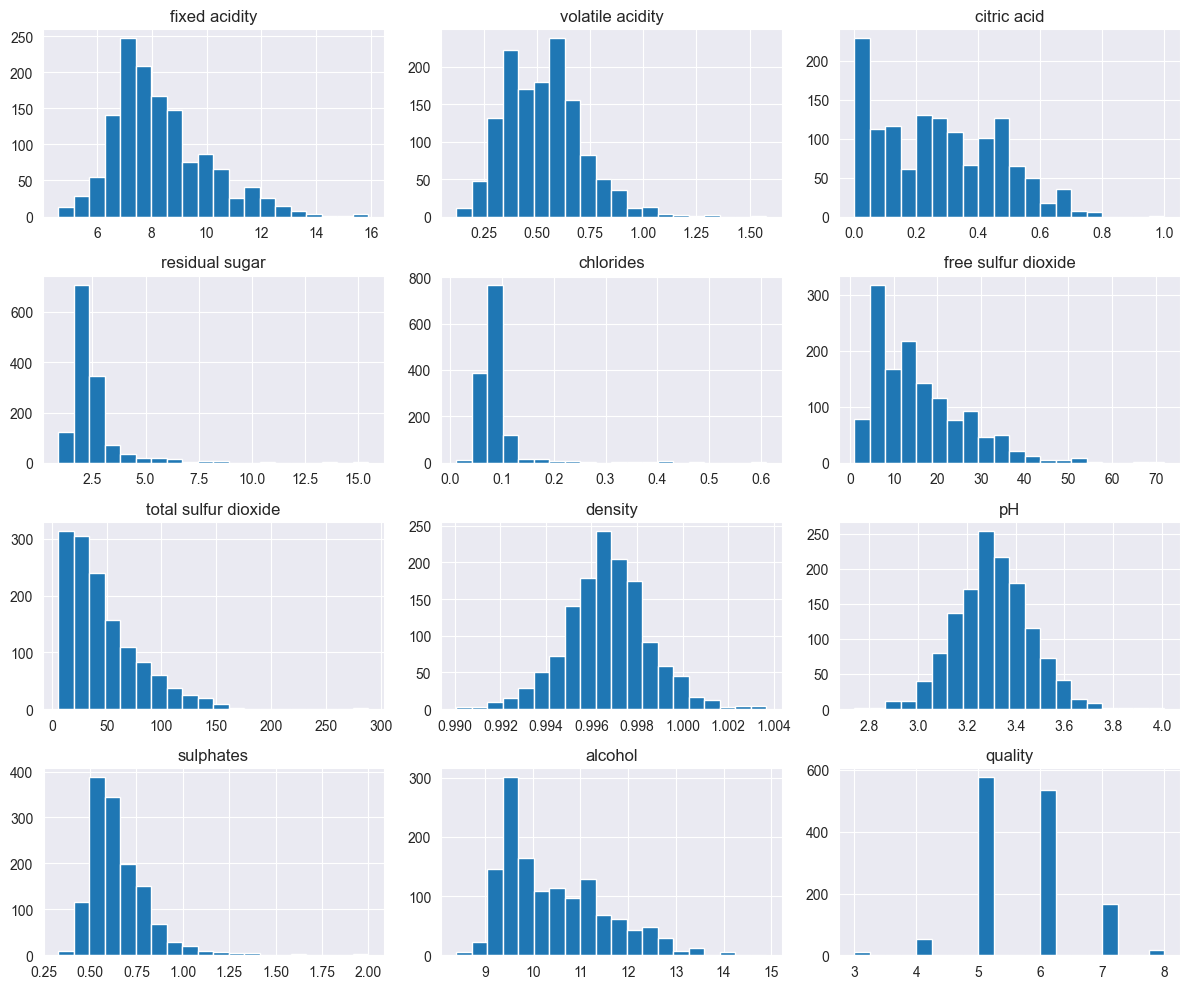

In [111]:
wine_data.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()


## 3.6 Matriz de Correlação

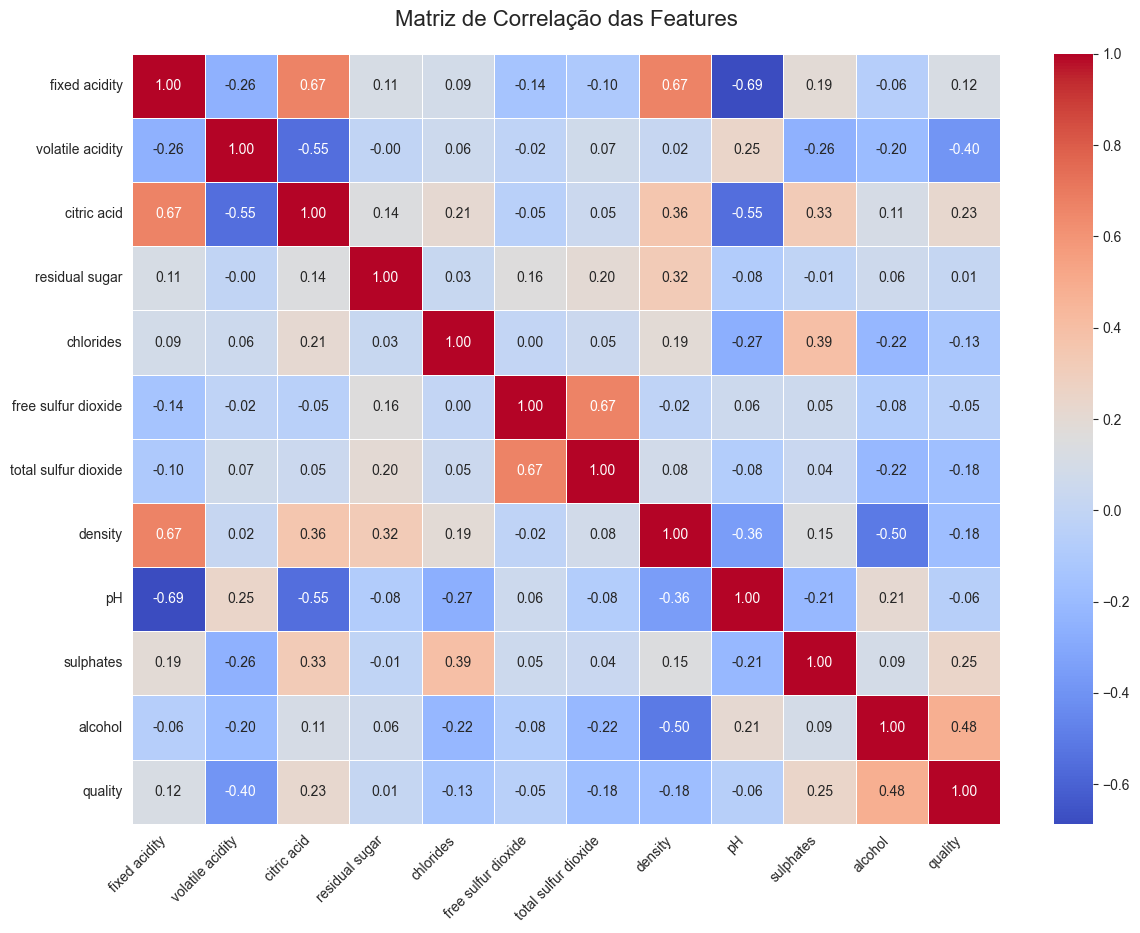

In [112]:
plt.figure(figsize=(14,10))

sns.heatmap(
    wine_data.corr(),
    annot=True,            # mostra valores
    fmt=".2f",             # 2 casas decimais
    cmap="coolwarm",       # mapa de cores perceptível
    linewidths=0.5,        # linhas entre células
    annot_kws={"size": 10} # tamanho do texto
)

plt.title("Matriz de Correlação das Features", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()



In [113]:
wine_data.corr()['quality'].sort_values(ascending=False)


quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64

## 3.6 Pairplot

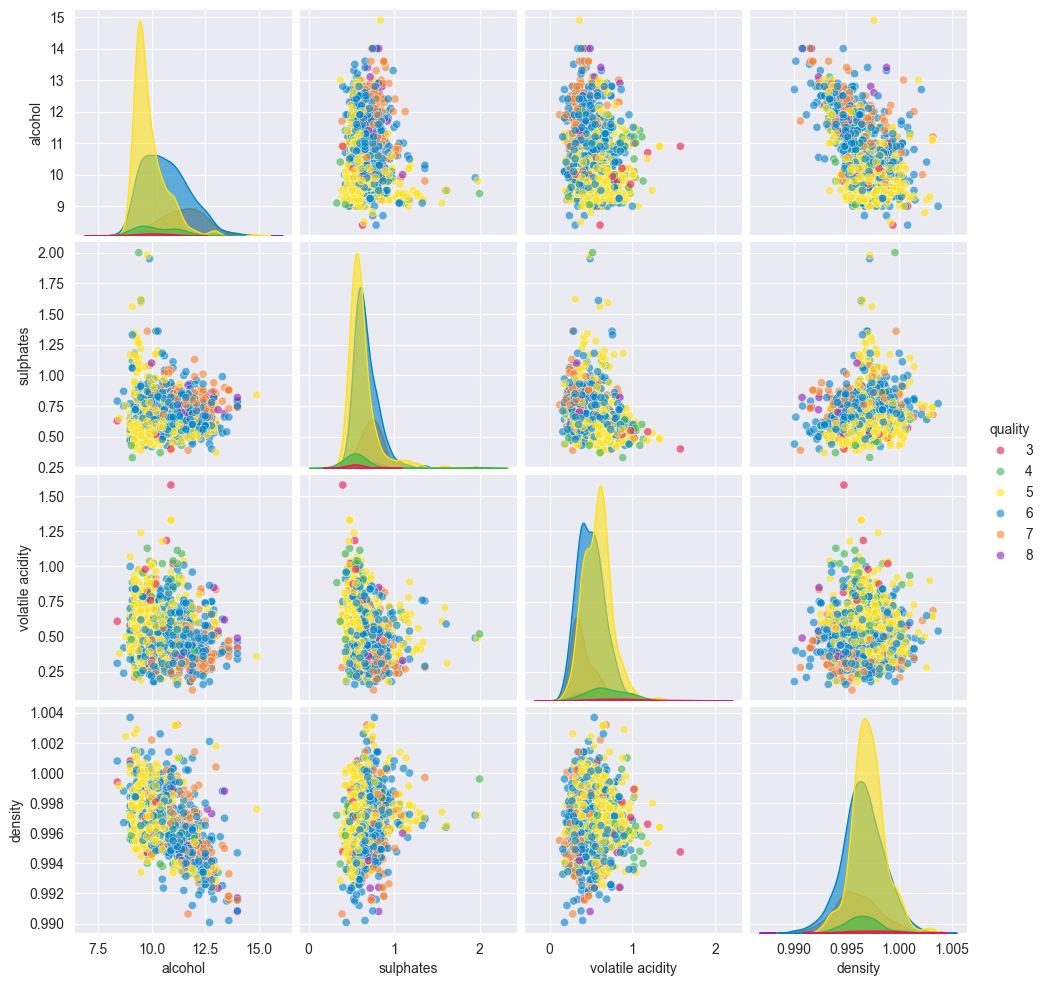

In [114]:
top_corr = ['alcohol', 'sulphates', 'volatile acidity', 'density', 'quality']
custom_palette = {
    3: '#e6194b',  # red
    4: '#3cb44b',  # green
    5: '#ffe119',  # yellow
    6: '#0082c8',  # blue
    7: '#f58231',  # orange
    8: '#911eb4'   # purple
}

sns.pairplot(
    wine_data[top_corr],
    hue='quality',
    palette=custom_palette,
    plot_kws={'alpha':0.6, 's':35},
    diag_kws={'alpha':0.6}
)





# 4. Conversão para Classificação Binária

## 4.1 Definição da Variável Target

In [115]:
wine_data_bi=wine_data.copy()

# 1. Criar a classificação binária baseada na regra:
# quality <= 5 -> 'under-average'
# quality >= 6 -> 'above-average'
wine_data_bi['Target'] = wine_data_bi['quality'].apply(lambda x: 1 if x >= 6 else 0)

wine_data_bi=wine_data_bi.drop(columns=['quality'])

wine_data_bi.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


## 4.2 Correlação com a Variável Binária

In [116]:
wine_data_bi.corr()['Target'].sort_values(ascending=False)


Target                  1.000000
alcohol                 0.446176
sulphates               0.211365
citric acid             0.167903
fixed acidity           0.091761
pH                      0.004693
residual sugar         -0.002371
free sulfur dioxide    -0.069207
chlorides              -0.115071
density                -0.168958
total sulfur dioxide   -0.235046
volatile acidity       -0.327195
Name: Target, dtype: float64

## 4.3 Distribuição da Classe Binária

In [117]:
wine_data_bi["Target"].value_counts()


Target
1    719
0    640
Name: count, dtype: int64

# 5. Pipeline de Classificação binaria (Dataset Completo)

## 5.1 Preparação dos Dados

- Separar X e y

In [118]:
X = wine_data_bi.drop(columns=['Target'])
y = wine_data_bi['Target']


- Train/Test Split (75/25 + stratify + random_state=42)


In [119]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


- Normalização (StandardScaler)

In [120]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5.2 Modelo NEURAL NETWORk (MLPClassifier)

### 5.2.1 Função de diagnóstico de overfitting/underfitting

In [121]:


def diagnosticar_neural_network(modelo, X_train, X_test, y_train, y_test, nome_modelo="Neural Network"):
    """
    Diagnóstica overfitting/underfitting numa Neural Network

    Parâmetros:
    -----------
    modelo : MLPClassifier já treinado
    X_train, X_test : dados de treino e teste (normalizados)
    y_train, y_test : labels de treino e teste
    nome_modelo : str, nome para identificar no output

    Retorna:
    --------
    dict com métricas de diagnóstico
    """

    # ========================================
    # 1. CALCULAR ACCURACIES
    # ========================================
    train_acc = modelo.score(X_train, y_train)
    test_acc = modelo.score(X_test, y_test)
    gap = train_acc - test_acc

    # ========================================
    # 2. IMPRIMIR RELATÓRIO
    # ========================================
    print("=" * 70)
    print(f" DIAGNÓSTICO: {nome_modelo}")
    print("=" * 70)

    # Performance
    print(f"\n1️ PERFORMANCE:")
    print(f"   Accuracy TREINO: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"   Accuracy TESTE:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Gap (diferença): {gap:.4f} ({gap*100:.2f}%)")

    # Convergência
    print(f"\n2️ CONVERGÊNCIA:")
    print(f"   Iterações usadas: {modelo.n_iter_} / {modelo.max_iter}")

    if modelo.n_iter_ == modelo.max_iter:
        print("    ATENÇÃO: Modelo NÃO convergiu (atingiu max_iter)")
        convergiu = False
    else:
        print("    Modelo convergiu antes do limite")
        convergiu = True

    # Loss final
    if len(modelo.loss_curve_) > 0:
        print(f"   Loss final: {modelo.loss_curve_[-1]:.6f}")

        # Verificar se loss ainda está a diminuir
        if len(modelo.loss_curve_) > 10:
            ultimas_10 = modelo.loss_curve_[-10:]
            variacao = np.std(ultimas_10)

            if variacao > 0.01:
                print(f"     Loss ainda instável (std={variacao:.4f})")
            else:
                print(f"    Loss estabilizado (std={variacao:.4f})")

    # ========================================
    # 3. DIAGNÓSTICO PRINCIPAL
    # ========================================
    print(f"\n3️ DIAGNÓSTICO:")

    if train_acc < 0.65 and test_acc < 0.65:
        diagnostico = "UNDERFITTING SEVERO"
        print(f"    {diagnostico}")
        print("    O modelo está MUITO FRACO em ambos os conjuntos")
        print("\n     AÇÕES RECOMENDADAS:")
        print("      1. Aumentar neurónios: ex: (128, 64) ou (200, 100)")
        print("      2. Aumentar max_iter para 1500 ou 2000")
        print("      3. VERIFICAR se os dados estão normalizados!")
        print("      4. Tentar activation='tanh'")
        print("      5. Aumentar learning_rate_init (ex: 0.01)")

    elif train_acc < 0.75 and test_acc < 0.75:
        diagnostico = "UNDERFITTING MODERADO"
        print(f"     {diagnostico}")
        print("    O modelo pode ser mais complexo")
        print("\n     AÇÕES RECOMENDADAS:")
        print("      1. Aumentar neurónios: ex: (100, 50) ou (128, 64)")
        print("      2. Adicionar uma camada: ex: (100, 50, 25)")
        print("      3. Aumentar max_iter se não convergiu")
        print("      4. Verificar feature engineering")

    elif gap > 0.2:
        diagnostico = "OVERFITTING SEVERO"
        print(f"    {diagnostico}")
        print(f"    Modelo DECOROU os dados de treino (gap = {gap:.4f})")
        print("\n     AÇÕES RECOMENDADAS:")
        print("      1. Aumentar alpha (regularização): 0.01 ou 0.1")
        print("      2. Usar early_stopping=True")
        print("      3. Diminuir neurónios: ex: (32, 16)")
        print("      4. Adicionar validation_fraction=0.1")
        print("      5. Reduzir max_iter")

    elif gap > 0.1:
        diagnostico = "OVERFITTING MODERADO"
        print(f"     {diagnostico}")
        print(f"    Há algum overfitting (gap = {gap:.4f})")
        print("\n     AÇÕES RECOMENDADAS:")
        print("      1. Aumentar alpha de 0.0001 para 0.001 ou 0.005")
        print("      2. Usar early_stopping=True")
        print("      3. Adicionar mais dados (se possível)")

    else:
        diagnostico = "BOM AJUSTE"
        print(f"    {diagnostico}")
        print(f"    Modelo bem equilibrado (gap = {gap:.4f})")
        print("\n     PRÓXIMOS PASSOS:")
        print("      1. Fazer Grid Search para fine-tuning")
        print("      2. Testar arquiteturas ligeiramente diferentes")
        print("      3. Validar com cross-validation")

    # Aviso especial sobre convergência
    if not convergiu:
        print(f"\n    CRÍTICO: Modelo não convergiu!")
        print(f"      → Aumentar max_iter de {modelo.max_iter} para pelo menos {modelo.max_iter * 2}")

    print("\n" + "=" * 70)

    # ========================================
    # 4. GRÁFICOS
    # ========================================
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfico 1: Loss Curve
    axes[0].plot(modelo.loss_curve_, linewidth=2, color='#3498db')
    axes[0].set_xlabel('Iterações', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Curva de Loss - {nome_modelo}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Adicionar anotação se não convergiu
    if not convergiu:
        axes[0].text(0.5, 0.95, ' NÃO CONVERGIU',
                     transform=axes[0].transAxes,
                     ha='center', va='top', fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))

    # Gráfico 2: Train vs Test Accuracy
    bars = axes[1].bar(['Treino', 'Teste'], [train_acc, test_acc],
                       color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black', linewidth=2)
    axes[1].set_ylim([0, 1.05])
    axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Treino vs Teste', fontsize=14, fontweight='bold')
    axes[1].axhline(y=0.7, color='orange', linestyle='--', alpha=0.5, label='Baseline (70%)')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}\n({height*100:.1f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Adicionar diagnóstico visual
    if "OVERFITTING" in diagnostico:
        axes[1].text(0.5, 0.5, f' {diagnostico}',
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='orange', alpha=0.6))
    elif "UNDERFITTING" in diagnostico:
        axes[1].text(0.5, 0.5, f' {diagnostico}',
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='red', alpha=0.6))
    else:
        axes[1].text(0.5, 0.5, f' {diagnostico}',
                     transform=axes[1].transAxes,
                     ha='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='green', alpha=0.6))

    plt.tight_layout()
    plt.show()

    # ========================================
    # 5. RETORNAR MÉTRICAS
    # ========================================
    return {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'gap': gap,
        'convergiu': convergiu,
        'diagnostico': diagnostico,
        'loss_final': modelo.loss_curve_[-1] if len(modelo.loss_curve_) > 0 else None
    }

### 5.2.2 FUNÇÃO DE AVALIAÇÃO COMPLETA DE MODELOS

In [122]:
# ====================================
# FUNÇÃO DE AVALIAÇÃO COMPLETA DE MODELOS
# ====================================


def avaliar_modelo(modelo, X_test, y_test, nome_modelo="Modelo", y_pred=None):
    """
    Avalia um modelo de classificação de forma completa e visual.

    Parâmetros:
    -----------
    modelo : modelo treinado (pode ser None se forneceres y_pred)
    X_test : features de teste
    y_test : labels verdadeiros de teste
    nome_modelo : str, nome do modelo para identificação
    y_pred : array opcional com previsões (se não fornecido, calcula automaticamente)

    Retorna:
    --------
    dict com todas as métricas
    """

    # Fazer previsões se não foram fornecidas
    if y_pred is None:
        if modelo is None:
            raise ValueError("Deves fornecer o modelo OU y_pred!")
        y_pred = modelo.predict(X_test)

    # ========================================
    # 1. CALCULAR MÉTRICAS
    # ========================================
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Métricas por classe
    precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # ROC AUC (se binário)
    classes = np.unique(y_test)
    if len(classes) == 2:
        try:
            if hasattr(modelo, 'predict_proba'):
                y_proba = modelo.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_proba)
            else:
                roc_auc = None
        except:
            roc_auc = None
    else:
        roc_auc = None

    # ========================================
    # 2. IMPRIMIR RELATÓRIO DETALHADO
    # ========================================
    print("\n" + "=" * 80)
    print(f" AVALIAÇÃO COMPLETA: {nome_modelo}")
    print("=" * 80)

    # Métricas Globais
    print("\n MÉTRICAS GLOBAIS (Weighted Average):")
    print("-" * 80)
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    if roc_auc is not None:
        print(f"   ROC AUC:   {roc_auc:.4f}")

    # Métricas Por Classe
    print("\n MÉTRICAS POR CLASSE:")
    print("-" * 80)
    print(f"{'Classe':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 80)

    for i, classe in enumerate(classes):
        support = np.sum(y_test == classe)
        print(f"{classe:<10} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} "
              f"{f1_per_class[i]:<12.4f} {support:<10}")

    print("-" * 80)

    # Classification Report (sklearn)
    print("\n CLASSIFICATION REPORT (Detalhado):")
    print("-" * 80)
    print(classification_report(y_test, y_pred, zero_division=0))

    # ========================================
    # 3. VISUALIZAÇÕES
    # ========================================

    # Configurar subplots
    if roc_auc is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- GRÁFICO 1: CONFUSION MATRIX ---
    ax1 = axes[0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=classes, yticklabels=classes, ax=ax1,
                annot_kws={"size": 14, "weight": "bold"})
    ax1.set_xlabel('Previsto', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax1.set_title(f'Confusion Matrix - {nome_modelo}', fontsize=14, fontweight='bold')

    # Adicionar percentagens
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax1.text(j+0.5, i+0.7, f'({cm_percent[i, j]:.1f}%)',
                    ha='center', va='center', fontsize=10, color='gray')

    # --- GRÁFICO 2: MÉTRICAS POR CLASSE ---
    ax2 = axes[1]
    x = np.arange(len(classes))
    width = 0.25

    bars1 = ax2.bar(x - width, precision_per_class, width, label='Precision', color='#3498db', alpha=0.8)
    bars2 = ax2.bar(x, recall_per_class, width, label='Recall', color='#2ecc71', alpha=0.8)
    bars3 = ax2.bar(x + width, f1_per_class, width, label='F1-Score', color='#e74c3c', alpha=0.8)

    ax2.set_xlabel('Classe', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_title(f'Métricas por Classe - {nome_modelo}', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(classes)
    ax2.legend()
    ax2.set_ylim([0, 1.05])
    ax2.grid(axis='y', alpha=0.3)

    # Adicionar valores nas barras
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    # --- GRÁFICO 3: ROC CURVE (se binário) ---
    if roc_auc is not None and hasattr(modelo, 'predict_proba'):
        ax3 = axes[2]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)

        ax3.plot(fpr, tpr, color='#e74c3c', linewidth=2,
                label=f'ROC Curve (AUC = {roc_auc:.4f})')
        ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
        ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        ax3.set_title(f'ROC Curve - {nome_modelo}', fontsize=14, fontweight='bold')
        ax3.legend(loc='lower right')
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========================================
    # 4. ANÁLISE ADICIONAL (Erros)
    # ========================================
    print("\n ANÁLISE DE ERROS:")
    print("-" * 80)

    # Contar erros
    erros = y_test != y_pred
    num_erros = np.sum(erros)
    total = len(y_test)

    print(f"   Total de previsões: {total}")
    print(f"   Acertos: {total - num_erros} ({(total - num_erros)/total*100:.2f}%)")
    print(f"   Erros: {num_erros} ({num_erros/total*100:.2f}%)")

    # Mostrar distribuição de erros
    if num_erros > 0:
        print("\n   Distribuição de Erros:")
        for classe in classes:
            erros_classe = np.sum((y_test == classe) & (y_test != y_pred))
            total_classe = np.sum(y_test == classe)
            if total_classe > 0:
                print(f"      Classe {classe}: {erros_classe}/{total_classe} "
                      f"({erros_classe/total_classe*100:.1f}% de erro)")

    print("\n" + "=" * 80)

    # ========================================
    # 5. RETORNAR MÉTRICAS
    # ========================================
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'num_erros': num_erros,
        'total': total
    }

## 5.3 Grid Search Customizado (Neural Network)

In [123]:


# ====================================
# GRID SEARCH CUSTOMIZADO COM VALIDAÇÃO INTELIGENTE
# ====================================


def grid_search_com_holdout_validation(X_train, X_test, y_train, y_test,
                                        param_grid,
                                        n_repeats=3,
                                        verbose=True):
    """
    Grid Search customizado que seleciona os melhores hiperparâmetros
    baseado na MELHOR TEST ACCURACY (não train accuracy).

    Para cada combinação de parâmetros:
    1. Treina N vezes com diferentes random_states
    2. Calcula média e std da test accuracy
    3. Seleciona a combinação com MAIOR test accuracy média

    Isto garante que escolhemos o modelo que GENERALIZA melhor,
    não o que decora melhor!

    Parâmetros:
    -----------
    X_train, X_test : dados de treino e teste (normalizados)
    y_train, y_test : labels
    param_grid : dict com parâmetros para testar
    n_repeats : quantas vezes treinar cada configuração (padrão: 5)
    verbose : mostrar progresso

    Retorna:
    --------
    dict com resultados completos
    """

    print("\n" + "="*90)
    print(" GRID SEARCH COM VALIDAÇÃO INTELIGENTE")
    print("="*90)
    print(f"Critério de seleção: MELHOR TEST ACCURACY (não train!)")
    print(f"Repetições por configuração: {n_repeats}")
    print("="*90)

    # Gerar todas as combinações possíveis
    param_combinations = list(ParameterGrid(param_grid))
    total_combinacoes = len(param_combinations)

    print(f"\n Total de combinações a testar: {total_combinacoes}")
    print(f" Total de treinos: {total_combinacoes * n_repeats}")
    print()

    # Mostrar grid
    print(" Espaço de busca:")
    for param, values in param_grid.items():
        print(f"   {param}: {values}")
    print()

    # Armazenar resultados
    resultados = []

    # Testar cada combinação
    for idx, params in enumerate(param_combinations, 1):
        if verbose:
            print(f"\n{'='*90}")
            print(f"  Config {idx}/{total_combinacoes}: {params}")
            print(f"{'='*90}")

        # Treinar n_repeats vezes com diferentes seeds
        train_accs = []
        test_accs = []
        gaps = []
        precisions = []
        recalls = []
        f1_scores = []
        n_iters = []
        convergiu_count = 0

        for seed in range(n_repeats):
            if verbose:
                print(f"   Run {seed+1}/{n_repeats}...", end=' ')

            # Adicionar random_state aos parâmetros
            params_with_seed = params.copy()
            params_with_seed['random_state'] = seed

            # Criar e treinar modelo
            nn = MLPClassifier(**params_with_seed)
            nn.fit(X_train, y_train)

            # Calcular métricas
            train_acc = nn.score(X_train, y_train)
            test_acc = nn.score(X_test, y_test)
            gap = train_acc - test_acc

            y_pred = nn.predict(X_test)
            precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            train_accs.append(train_acc)
            test_accs.append(test_acc)
            gaps.append(gap)
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)
            n_iters.append(nn.n_iter_)

            if nn.n_iter_ < nn.max_iter:
                convergiu_count += 1

            if verbose:
                print(f"Test={test_acc:.4f}, Gap={gap:.4f}")

        # Calcular estatísticas
        test_acc_mean = np.mean(test_accs)
        test_acc_std = np.std(test_accs)
        train_acc_mean = np.mean(train_accs)
        train_acc_std = np.std(train_accs)
        gap_mean = np.mean(gaps)
        gap_std = np.std(gaps)

        if verbose:
            print(f"\n    Resultados:")
            print(f"      Test Acc:  {test_acc_mean:.4f} ± {test_acc_std:.4f}")
            print(f"      Train Acc: {train_acc_mean:.4f} ± {train_acc_std:.4f}")
            print(f"      Gap:       {gap_mean:.4f} ± {gap_std:.4f}")
            print(f"      Convergiu: {convergiu_count}/{n_repeats}")

        # Guardar resultados
        resultados.append({
            'params': params,
            'test_acc_mean': test_acc_mean,
            'test_acc_std': test_acc_std,
            'test_acc_min': np.min(test_accs),
            'test_acc_max': np.max(test_accs),
            'train_acc_mean': train_acc_mean,
            'train_acc_std': train_acc_std,
            'gap_mean': gap_mean,
            'gap_std': gap_std,
            'precision_mean': np.mean(precisions),
            'recall_mean': np.mean(recalls),
            'f1_mean': np.mean(f1_scores),
            'n_iter_mean': np.mean(n_iters),
            'pct_convergiu': (convergiu_count / n_repeats) * 100,
            'test_accs_all': test_accs,
            'train_accs_all': train_accs
        })

    # Criar DataFrame com resultados
    df_results = pd.DataFrame(resultados)

    # Ordenar por test_acc_mean (CRITÉRIO DE SELEÇÃO!)
    df_results = df_results.sort_values('test_acc_mean', ascending=False).reset_index(drop=True)

    # Identificar o melhor
    melhor = df_results.iloc[0]
    melhor_params = melhor['params']

    # ========================================
    # RELATÓRIO FINAL
    # ========================================
    print("\n" + "="*90)
    print(" RESULTADOS DO GRID SEARCH")
    print("="*90)

    print("\n TOP 5 MELHORES CONFIGURAÇÕES (por Test Accuracy):")
    print("-"*90)

    for i in range(min(5, len(df_results))):
        config = df_results.iloc[i]
        print(f"\n{i+1}º lugar:")
        print(f"   Parâmetros: {config['params']}")
        print(f"   Test Acc:  {config['test_acc_mean']:.4f} ± {config['test_acc_std']:.4f}")
        print(f"   Train Acc: {config['train_acc_mean']:.4f} ± {config['train_acc_std']:.4f}")
        print(f"   Gap:       {config['gap_mean']:.4f} ± {config['gap_std']:.4f}")

    print("\n" + "="*90)
    print(" MELHOR CONFIGURAÇÃO SELECIONADA:")
    print("="*90)
    for param, value in melhor_params.items():
        print(f"   {param}: {value}")

    print(f"\n Performance da Melhor Configuração:")
    print(f"   Test Accuracy:")
    print(f"      Média: {melhor['test_acc_mean']:.4f} ({melhor['test_acc_mean']*100:.2f}%)")
    print(f"      Std:   {melhor['test_acc_std']:.4f}")
    print(f"      Min:   {melhor['test_acc_min']:.4f}")
    print(f"      Max:   {melhor['test_acc_max']:.4f}")

    print(f"\n   Train Accuracy:")
    print(f"      Média: {melhor['train_acc_mean']:.4f} ({melhor['train_acc_mean']*100:.2f}%)")
    print(f"      Std:   {melhor['train_acc_std']:.4f}")

    print(f"\n   Overfitting (Gap):")
    print(f"      Média: {melhor['gap_mean']:.4f} ({melhor['gap_mean']*100:.2f}%)")
    print(f"      Std:   {melhor['gap_std']:.4f}")

    print(f"\n   Outras Métricas:")
    print(f"      Precision: {melhor['precision_mean']:.4f}")
    print(f"      Recall:    {melhor['recall_mean']:.4f}")
    print(f"      F1-Score:  {melhor['f1_mean']:.4f}")

    print(f"\n   Convergência:")
    print(f"      % que convergiu: {melhor['pct_convergiu']:.1f}%")
    print(f"      Iterações médias: {melhor['n_iter_mean']:.1f}")

    print("\n" + "="*90)

    # ========================================
    # VISUALIZAÇÕES
    # ========================================

    # Gráfico 1: Comparação de todas as configurações
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # --- GRÁFICO 1: Test Accuracy por Configuração ---
    ax1 = axes[0, 0]
    configs_labels = [f"Config {i+1}" for i in range(len(df_results))]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_results))]

    bars = ax1.barh(configs_labels, df_results['test_acc_mean'],
                    xerr=df_results['test_acc_std'], color=colors, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Test Accuracy (Média ± Std)', fontsize=12, fontweight='bold')
    ax1.set_title('Test Accuracy por Configuração', fontsize=14, fontweight='bold')
    ax1.axvline(melhor['test_acc_mean'], color='red', linestyle='--', linewidth=2,
                label=f"Melhor: {melhor['test_acc_mean']:.4f}")
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()

    # --- GRÁFICO 2: Train vs Test (Scatter) ---
    ax2 = axes[0, 1]
    scatter = ax2.scatter(df_results['train_acc_mean'], df_results['test_acc_mean'],
                          s=200, c=df_results['gap_mean'], cmap='RdYlGn_r',
                          alpha=0.7, edgecolor='black', linewidth=2)

    # Destacar o melhor
    ax2.scatter(melhor['train_acc_mean'], melhor['test_acc_mean'],
                s=400, marker='*', color='gold', edgecolor='black', linewidth=3,
                label='Melhor Config', zorder=5)

    # Linha diagonal
    min_val = min(df_results['train_acc_mean'].min(), df_results['test_acc_mean'].min())
    max_val = max(df_results['train_acc_mean'].max(), df_results['test_acc_mean'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
             label='Train = Test (ideal)', alpha=0.7)

    ax2.set_xlabel('Train Accuracy', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Gap (Overfitting)', fontsize=10)

    # --- GRÁFICO 3: Box Plot do Gap ---
    ax3 = axes[1, 0]
    gap_data = [df_results.iloc[i]['train_accs_all'] - np.array(df_results.iloc[i]['test_accs_all'])
                for i in range(len(df_results))]

    bp = ax3.boxplot(gap_data, labels=configs_labels, patch_artist=True, vert=False)
    for i, patch in enumerate(bp['boxes']):
        if i == 0:
            patch.set_facecolor('#2ecc71')
        else:
            patch.set_facecolor('#3498db')
        patch.set_alpha(0.7)

    ax3.set_xlabel('Gap (Train - Test)', fontsize=12, fontweight='bold')
    ax3.set_title('Distribuição do Gap por Configuração', fontsize=14, fontweight='bold')
    ax3.axvline(0.1, color='orange', linestyle=':', linewidth=2, label='Limite (0.1)')
    ax3.legend()
    ax3.grid(axis='x', alpha=0.3)

    # --- GRÁFICO 4: Tabela Resumo ---
    ax4 = axes[1, 1]
    ax4.axis('off')

    # Criar tabela com top 5
    tabela_dados = [['Config', 'Test Acc', 'Gap', 'Conv%']]
    for i in range(min(5, len(df_results))):
        config = df_results.iloc[i]
        tabela_dados.append([
            f"Config {i+1}",
            f"{config['test_acc_mean']:.4f} ± {config['test_acc_std']:.4f}",
            f"{config['gap_mean']:.4f}",
            f"{config['pct_convergiu']:.0f}%"
        ])

    table = ax4.table(cellText=tabela_dados, cellLoc='center', loc='center',
                     colWidths=[0.2, 0.35, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)

    # Estilizar header
    for j in range(4):
        table[(0, j)].set_facecolor('#3498db')
        table[(0, j)].set_text_props(weight='bold', color='white')

    # Destacar melhor
    for j in range(4):
        table[(1, j)].set_facecolor('#2ecc71')
        table[(1, j)].set_text_props(weight='bold')

    ax4.set_title('Top 5 Configurações', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

    # ========================================
    # RETORNAR RESULTADOS
    # ========================================
    return {
        'melhor_params': melhor_params,
        'melhor_config': melhor,
        'df_results': df_results,
        'todas_configs': resultados
    }

## 5.5 Ensemble de 30 Neural Networks

In [124]:



def ensemble_mlp_full(X_train, X_test, y_train, y_test, params):

    test_accs = []
    train_accs = []
    precs = []
    recs = []
    f1s = []
    aucs = []
    gaps = []

    # --- novos vetores (por classe) ---
    precs_per_class = []
    recs_per_class = []
    f1s_per_class = []

    modelos = []

    print("\n==============================")
    print(" TREINAR 30 MODELOS MLP (Neural Network)")
    print("==============================\n")

    for i in range(30):

        mlp = MLPClassifier(**params, random_state=42 + i)
        mlp.fit(X_train, y_train)

        # previsões
        y_pred_test = mlp.predict(X_test)
        y_pred_train = mlp.predict(X_train)

        # métricas globais
        test_acc = accuracy_score(y_test, y_pred_test)
        train_acc = accuracy_score(y_train, y_pred_train)

        precision = precision_score(y_test, y_pred_test, average='weighted')
        recall = recall_score(y_test, y_pred_test, average='weighted')
        f1 = f1_score(y_test, y_pred_test, average='weighted')

        try:
            auc = roc_auc_score(y_test, mlp.predict_proba(X_test), multi_class='ovr')
        except:
            auc = np.nan

        gap = train_acc - test_acc

        # métricas por classe
        prec_pc = precision_score(y_test, y_pred_test, average=None)
        rec_pc = recall_score(y_test, y_pred_test, average=None)
        f1_pc = f1_score(y_test, y_pred_test, average=None)

        # guardar tudo
        test_accs.append(test_acc)
        train_accs.append(train_acc)
        precs.append(precision)
        recs.append(recall)
        f1s.append(f1)
        aucs.append(auc)
        gaps.append(gap)

        precs_per_class.append(prec_pc)
        recs_per_class.append(rec_pc)
        f1s_per_class.append(f1_pc)

        modelos.append((mlp, test_acc))

        print(f"Modelo {i+1:02d}/30 -> Test Accuracy: {test_acc:.4f}")

    # -----------------------------
    #   Estatísticas gerais
    # -----------------------------
    test_accs = np.array(test_accs)

    mean_ = np.mean(test_accs)
    std_ = np.std(test_accs, ddof=1)
    se_ = std_ / np.sqrt(len(test_accs))
    median_ = np.median(test_accs)
    min_ = np.min(test_accs)
    max_ = np.max(test_accs)
    q1_ = np.percentile(test_accs, 25)
    q3_ = np.percentile(test_accs, 75)
    iqr_ = q3_ - q1_
    cv_ = (std_ / mean_) * 100

    ic95_low = mean_ - 1.96 * se_
    ic95_high = mean_ + 1.96 * se_

    best_model, best_acc = max(modelos, key=lambda x: x[1])

    # --------------------------------
    #       ESTATÍSTICAS EXTRA
    # --------------------------------

    precs_per_class = np.array(precs_per_class)
    recs_per_class = np.array(recs_per_class)
    f1s_per_class = np.array(f1s_per_class)

    mean_prec_pc = np.mean(precs_per_class, axis=0)
    std_prec_pc = np.std(precs_per_class, axis=0, ddof=1)

    mean_rec_pc = np.mean(recs_per_class, axis=0)
    std_rec_pc = np.std(recs_per_class, axis=0, ddof=1)

    mean_f1_pc = np.mean(f1s_per_class, axis=0)
    std_f1_pc = np.std(f1s_per_class, axis=0, ddof=1)

    # --------------------------------
    #       PRINT FINAL
    # --------------------------------
    print("\n==========================================")
    print("     ESTATÍSTICAS DO ENSEMBLE (30 MLP)")
    print("==========================================\n")

    print(f"   Média (μ):               {mean_:.4f} ({mean_*100:.2f}%)")
    print(f"   Desvio Padrão (σ):       {std_:.4f} ({std_*100:.2f}%)")
    print(f"   Standard Error (SE):     {se_:.4f}")
    print(f"   Mediana:                 {median_:.4f} ({median_*100:.2f}%)")
    print(f"   Mínimo:                  {min_:.4f} ({min_*100:.2f}%)")
    print(f"   Máximo:                  {max_:.4f} ({max_*100:.2f}%)")
    print(f"   Quartil 1 (Q1):          {q1_:.4f}")
    print(f"   Quartil 3 (Q3):          {q3_:.4f}")
    print(f"   IQR (Q3 - Q1):           {iqr_:.4f}")
    print(f"   Coef. Variação (CV):     {cv_:.2f}%")

    print("\nINTERVALO DE CONFIANÇA (95%):")
    print(f"   [{ic95_low:.4f}, {ic95_high:.4f}]")

    print("\n OUTRAS MÉTRICAS (Média ± Std):")
    print("------------------------------------------------------------------")
    print(f"   Train Accuracy:  {np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}")
    print(f"   Test Accuracy:   {np.mean(test_accs):.4f} ± {np.std(test_accs, ddof=1):.4f}")
    print(f"   Precision:       {np.mean(precs):.4f} ± {np.std(precs, ddof=1):.4f}")
    print(f"   Recall:          {np.mean(recs):.4f} ± {np.std(recs, ddof=1):.4f}")
    print(f"   F1-Score:        {np.mean(f1s):.4f} ± {np.std(f1s, ddof=1):.4f}")
    print(f"   Gap (Overfit):   {np.mean(gaps):.4f} ± {np.std(gaps, ddof=1):.4f}")

    print("\n MÉTRICAS POR CLASSE (Média ± Std):")
    print("------------------------------------------------------------------")
    n_classes = precs_per_class.shape[1]
    for c in range(n_classes):
        print(f"   Classe {c}:")
        print(f"      Precision: {mean_prec_pc[c]:.4f} ± {std_prec_pc[c]:.4f}")
        print(f"      Recall:    {mean_rec_pc[c]:.4f} ± {std_rec_pc[c]:.4f}")
        print(f"      F1-Score:  {mean_f1_pc[c]:.4f} ± {std_f1_pc[c]:.4f}")

    print(f"\n   Melhor Modelo Accuracy:  {best_acc:.4f} ({best_acc*100:.2f}%)")

    return best_model, test_accs


In [125]:

params_mlp = {
    'activation': 'tanh',
    'alpha': 0.05,
    'hidden_layer_sizes': (64,),
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 2500,
    'solver': 'sgd'
}

best_mlp, mlp_accs = ensemble_mlp_full(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    params_mlp
)



 TREINAR 30 MODELOS MLP (Neural Network)

Modelo 01/30 -> Test Accuracy: 0.7441
Modelo 02/30 -> Test Accuracy: 0.7647
Modelo 03/30 -> Test Accuracy: 0.7353
Modelo 04/30 -> Test Accuracy: 0.7618
Modelo 05/30 -> Test Accuracy: 0.7706
Modelo 06/30 -> Test Accuracy: 0.7529
Modelo 07/30 -> Test Accuracy: 0.7471
Modelo 08/30 -> Test Accuracy: 0.7500
Modelo 09/30 -> Test Accuracy: 0.7618
Modelo 10/30 -> Test Accuracy: 0.7441
Modelo 11/30 -> Test Accuracy: 0.7588
Modelo 12/30 -> Test Accuracy: 0.7618
Modelo 13/30 -> Test Accuracy: 0.7324
Modelo 14/30 -> Test Accuracy: 0.7471
Modelo 15/30 -> Test Accuracy: 0.7588
Modelo 16/30 -> Test Accuracy: 0.7676
Modelo 17/30 -> Test Accuracy: 0.7529
Modelo 18/30 -> Test Accuracy: 0.7647
Modelo 19/30 -> Test Accuracy: 0.7588
Modelo 20/30 -> Test Accuracy: 0.7529
Modelo 21/30 -> Test Accuracy: 0.7706
Modelo 22/30 -> Test Accuracy: 0.7471
Modelo 23/30 -> Test Accuracy: 0.7676
Modelo 24/30 -> Test Accuracy: 0.7706
Modelo 25/30 -> Test Accuracy: 0.7412
Modelo 

# 6. Modelo Random Forest (Dataset Completo)

## 6.1 Grid Search Customizado

In [126]:


def grid_search_rf_com_holdout_validation(X_train, X_test, y_train, y_test,
                                          param_grid,
                                          n_repeats=3,
                                          verbose=True):
    """
    Grid Search customizado para RANDOM FOREST usando validação holdout
    e repetição com diferentes seeds.

    Seleciona o melhor modelo baseado na MAIOR TEST ACCURACY média.
    """

    print("\n" + "="*90)
    print(" GRID SEARCH RANDOM FOREST — VALIDAÇÃO INTELIGENTE")
    print("="*90)
    print(f"Critério: MELHOR TEST ACCURACY")
    print(f"Repetições por configuração: {n_repeats}")
    print("="*90)

    param_combinations = list(ParameterGrid(param_grid))
    total_combinacoes = len(param_combinations)

    print(f"\n Total de combinações: {total_combinacoes}")
    print(f" Total de treinos: {total_combinacoes * n_repeats}")
    print("\n Espaço de busca:")
    for p, v in param_grid.items():
        print(f"   {p}: {v}")
    print()

    resultados = []

    for idx, params in enumerate(param_combinations, 1):

        if verbose:
            print("\n" + "="*90)
            print(f" Config {idx}/{total_combinacoes}: {params}")
            print("="*90)

        train_accs, test_accs = [], []
        precisions, recalls, f1s = [], [], []
        gaps = []
        convergiu_count = n_repeats  # RF converge sempre

        for seed in range(n_repeats):

            if verbose:
                print(f"   Run {seed+1}/{n_repeats}...", end=' ')

            modelo = RandomForestClassifier(
                random_state=seed,
                **params
            )
            modelo.fit(X_train, y_train)

            # Predições
            y_pred = modelo.predict(X_test)

            # Métricas
            train_acc = modelo.score(X_train, y_train)
            test_acc = modelo.score(X_test, y_test)
            gap = train_acc - test_acc
            precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            train_accs.append(train_acc)
            test_accs.append(test_acc)
            gaps.append(gap)
            precisions.append(precision)
            recalls.append(recall)
            f1s.append(f1)

            if verbose:
                print(f"Test={test_acc:.4f}, Gap={gap:.4f}")

        # Estatísticas
        resultados.append({
            'params': params,
            'test_acc_mean': np.mean(test_accs),
            'test_acc_std': np.std(test_accs),
            'test_acc_min': np.min(test_accs),
            'test_acc_max': np.max(test_accs),
            'train_acc_mean': np.mean(train_accs),
            'train_acc_std': np.std(train_accs),
            'gap_mean': np.mean(gaps),
            'gap_std': np.std(gaps),
            'precision_mean': np.mean(precisions),
            'recall_mean': np.mean(recalls),
            'f1_mean': np.mean(f1s),
            'n_iter_mean': None,
            'pct_convergiu': 100.0,
            'test_accs_all': test_accs,
            'train_accs_all': train_accs
        })

    df_results = pd.DataFrame(resultados)
    df_results = df_results.sort_values('test_acc_mean', ascending=False).reset_index(drop=True)
    melhor = df_results.iloc[0]
    melhor_params = melhor['params']

    # ========================================
    # RELATÓRIO
    # ========================================
    print("\n" + "="*90)
    print(" MELHORES CONFIGURAÇÕES RANDOM FOREST")
    print("="*90)
    for i in range(min(5, len(df_results))):
        config = df_results.iloc[i]
        print(f"\n{i+1}º lugar:")
        print(f"   Parâmetros: {config['params']}")
        print(f"   Test Acc:  {config['test_acc_mean']:.4f} ± {config['test_acc_std']:.4f}")
        print(f"   Train Acc: {config['train_acc_mean']:.4f} ± {config['train_acc_std']:.4f}")
        print(f"   Gap:       {config['gap_mean']:.4f}")

    print("\n" + "="*90)
    print(" MELHOR MODELO FINAL (RF)")
    print("="*90)
    for param, value in melhor_params.items():
        print(f"   {param}: {value}")

    print(f"\nTest Accuracy: {melhor['test_acc_mean']:.4f} ± {melhor['test_acc_std']:.4f}")
    print(f"Train Accuracy: {melhor['train_acc_mean']:.4f}")
    print(f"Gap médio: {melhor['gap_mean']:.4f}")
    print(f"F1 médio: {melhor['f1_mean']:.4f}")


    return {
        'melhor_params': melhor_params,
        'melhor_config': melhor,
        'df_results': df_results,
        'todas_configs': resultados
    }


In [127]:
'''param_grid_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
rf_results = grid_search_rf_com_holdout_validation(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    param_grid_rf,
    n_repeats=3,      # igual à NN
    verbose=True      # podes meter False se quiseres
)'''


"param_grid_rf = {\n    'n_estimators': [200, 300, 500],\n    'max_depth': [None, 5, 10, 20],\n    'min_samples_split': [2, 5, 10],\n    'min_samples_leaf': [1, 2, 4],\n    'bootstrap': [True, False]\n}\nrf_results = grid_search_rf_com_holdout_validation(\n    X_train_scaled,\n    X_test_scaled,\n    y_train,\n    y_test,\n    param_grid_rf,\n    n_repeats=3,      # igual à NN\n    verbose=True      # podes meter False se quiseres\n)"

## 6.2 Ensemble de 30 Random Forests

In [128]:


def ensemble_rf_full(X_train, X_test, y_train, y_test, params):

    test_accs = []
    train_accs = []
    precs = []
    recs = []
    f1s = []
    aucs = []
    gaps = []

    # --- novos vetores (por classe) ---
    precs_per_class = []
    recs_per_class = []
    f1s_per_class = []

    modelos = []

    print("\n==============================")
    print(" TREINAR 30 MODELOS RANDOM FOREST")
    print("==============================\n")

    for i in range(30):
        rf = RandomForestClassifier(**params, random_state=42 + i)
        rf.fit(X_train, y_train)

        # previsões
        y_pred_test = rf.predict(X_test)
        y_pred_train = rf.predict(X_train)

        # métricas globais
        test_acc = accuracy_score(y_test, y_pred_test)
        train_acc = accuracy_score(y_train, y_pred_train)

        precision = precision_score(y_test, y_pred_test, average='weighted')
        recall = recall_score(y_test, y_pred_test, average='weighted')
        f1 = f1_score(y_test, y_pred_test, average='weighted')

        try:
            auc = roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr')
        except:
            auc = np.nan

        gap = train_acc - test_acc

        # métricas por classe
        prec_pc = precision_score(y_test, y_pred_test, average=None)
        rec_pc = recall_score(y_test, y_pred_test, average=None)
        f1_pc = f1_score(y_test, y_pred_test, average=None)

        # guardar tudo
        test_accs.append(test_acc)
        train_accs.append(train_acc)
        precs.append(precision)
        recs.append(recall)
        f1s.append(f1)
        aucs.append(auc)
        gaps.append(gap)

        precs_per_class.append(prec_pc)
        recs_per_class.append(rec_pc)
        f1s_per_class.append(f1_pc)

        modelos.append((rf, test_acc))

        print(f"Modelo {i+1:02d}/30 -> Test Accuracy: {test_acc:.4f}")

    # -----------------------------
    #   Estatísticas gerais
    # -----------------------------
    test_accs = np.array(test_accs)

    mean_ = np.mean(test_accs)
    std_ = np.std(test_accs, ddof=1)
    se_ = std_ / np.sqrt(len(test_accs))
    median_ = np.median(test_accs)
    min_ = np.min(test_accs)
    max_ = np.max(test_accs)
    q1_ = np.percentile(test_accs, 25)
    q3_ = np.percentile(test_accs, 75)
    iqr_ = q3_ - q1_
    cv_ = (std_ / mean_) * 100

    ic95_low = mean_ - 1.96 * se_
    ic95_high = mean_ + 1.96 * se_

    best_model, best_acc = max(modelos, key=lambda x: x[1])

    # --------------------------------
    #       ESTATÍSTICAS EXTRA
    # --------------------------------

    # converter listas → arrays (30 × n_classes)
    precs_per_class = np.array(precs_per_class)
    recs_per_class = np.array(recs_per_class)
    f1s_per_class = np.array(f1s_per_class)

    # médias e desvios por classe
    mean_prec_pc = np.mean(precs_per_class, axis=0)
    std_prec_pc = np.std(precs_per_class, axis=0, ddof=1)

    mean_rec_pc = np.mean(recs_per_class, axis=0)
    std_rec_pc = np.std(recs_per_class, axis=0, ddof=1)

    mean_f1_pc = np.mean(f1s_per_class, axis=0)
    std_f1_pc = np.std(f1s_per_class, axis=0, ddof=1)

    # --------------------------------
    #       PRINT FINAL
    # --------------------------------
    print("\n==========================================")
    print("     ESTATÍSTICAS DO ENSEMBLE (30 RF)")
    print("==========================================\n")

    print(f"   Média (μ):               {mean_:.4f} ({mean_*100:.2f}%)")
    print(f"   Desvio Padrão (σ):       {std_:.4f} ({std_*100:.2f}%)")
    print(f"   Standard Error (SE):     {se_:.4f}")
    print(f"   Mediana:                 {median_:.4f} ({median_*100:.2f}%)")
    print(f"   Mínimo:                  {min_:.4f} ({min_*100:.2f}%)")
    print(f"   Máximo:                  {max_:.4f} ({max_*100:.2f}%)")
    print(f"   Quartil 1 (Q1):          {q1_:.4f}")
    print(f"   Quartil 3 (Q3):          {q3_:.4f}")
    print(f"   IQR (Q3 - Q1):           {iqr_:.4f}")
    print(f"   Coef. Variação (CV):     {cv_:.2f}%")

    print("\nINTERVALO DE CONFIANÇA (95%):")
    print(f"   [{ic95_low:.4f}, {ic95_high:.4f}]")

    print("\n OUTRAS MÉTRICAS (Média ± Std):")
    print("------------------------------------------------------------------")
    print(f"   Train Accuracy:  {np.mean(train_accs):.4f} ± {np.std(train_accs, ddof=1):.4f}")
    print(f"   Test Accuracy:   {np.mean(test_accs):.4f} ± {np.std(test_accs, ddof=1):.4f}")
    print(f"   Precision:       {np.mean(precs):.4f} ± {np.std(precs, ddof=1):.4f}")
    print(f"   Recall:          {np.mean(recs):.4f} ± {np.std(recs, ddof=1):.4f}")
    print(f"   F1-Score:        {np.mean(f1s):.4f} ± {np.std(f1s, ddof=1):.4f}")
    print(f"   Gap (Overfit):   {np.mean(gaps):.4f} ± {np.std(gaps, ddof=1):.4f}")

    print("\n MÉTRICAS POR CLASSE (Média ± Std):")
    print("------------------------------------------------------------------")
    n_classes = precs_per_class.shape[1]
    for c in range(n_classes):
        print(f"   Classe {c}:")
        print(f"      Precision: {mean_prec_pc[c]:.4f} ± {std_prec_pc[c]:.4f}")
        print(f"      Recall:    {mean_rec_pc[c]:.4f} ± {std_rec_pc[c]:.4f}")
        print(f"      F1-Score:  {mean_f1_pc[c]:.4f} ± {std_f1_pc[c]:.4f}")

    print(f"\n   Melhor Modelo Accuracy:  {best_acc:.4f} ({best_acc*100:.2f}%)")

    return best_model, test_accs


In [129]:
rf_params = {
    'bootstrap': True,
    'max_depth': 5,
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'n_estimators': 200
}

best_rf, accs = ensemble_rf_full(
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    rf_params
)



 TREINAR 30 MODELOS RANDOM FOREST

Modelo 01/30 -> Test Accuracy: 0.7765
Modelo 02/30 -> Test Accuracy: 0.7824
Modelo 03/30 -> Test Accuracy: 0.7794
Modelo 04/30 -> Test Accuracy: 0.7824
Modelo 05/30 -> Test Accuracy: 0.7735
Modelo 06/30 -> Test Accuracy: 0.7735
Modelo 07/30 -> Test Accuracy: 0.7765
Modelo 08/30 -> Test Accuracy: 0.7706
Modelo 09/30 -> Test Accuracy: 0.7706
Modelo 10/30 -> Test Accuracy: 0.7618
Modelo 11/30 -> Test Accuracy: 0.7647
Modelo 12/30 -> Test Accuracy: 0.7735
Modelo 13/30 -> Test Accuracy: 0.7853
Modelo 14/30 -> Test Accuracy: 0.7765
Modelo 15/30 -> Test Accuracy: 0.7706
Modelo 16/30 -> Test Accuracy: 0.7794
Modelo 17/30 -> Test Accuracy: 0.7794
Modelo 18/30 -> Test Accuracy: 0.7765
Modelo 19/30 -> Test Accuracy: 0.7765
Modelo 20/30 -> Test Accuracy: 0.7765
Modelo 21/30 -> Test Accuracy: 0.7824
Modelo 22/30 -> Test Accuracy: 0.7735
Modelo 23/30 -> Test Accuracy: 0.7735
Modelo 24/30 -> Test Accuracy: 0.7794
Modelo 25/30 -> Test Accuracy: 0.7794
Modelo 26/30 -

# 7. Modelo SVM (Dataset Completo)

## 7.1 Grid Search Customizado

In [130]:
from sklearn.svm import SVC

def grid_search_svm_com_holdout_validation(X_train, X_test, y_train, y_test,
                                           param_grid,
                                           n_repeats=3,
                                           verbose=True):

    print("\n" + "="*90)
    print(" GRID SEARCH SVM — VALIDAÇÃO INTELIGENTE")
    print("="*90)
    print(f"Critério: MELHOR TEST ACCURACY")
    print(f"Repetições por configuração: {n_repeats}")
    print("="*90)

    param_combinations = list(ParameterGrid(param_grid))
    total_combinacoes = len(param_combinations)

    print(f"\n Total de combinações: {total_combinacoes}")
    print(f" Total de treinos: {total_combinacoes * n_repeats}")
    print("\n Espaço de busca:")
    for p, v in param_grid.items():
        print(f"   {p}: {v}")
    print()

    resultados = []

    for idx, params in enumerate(param_combinations, 1):

        if verbose:
            print("\n" + "="*90)
            print(f" Config {idx}/{total_combinacoes}: {params}")
            print("="*90)

        train_accs, test_accs = [], []
        precisions, recalls, f1s = [], [], []
        gaps = []
        convergiu_count = n_repeats  # SVM converge sempre

        for seed in range(n_repeats):

            if verbose:
                print(f"   Run {seed+1}/{n_repeats}...", end=' ')

            modelo = SVC(**params)
            modelo.fit(X_train, y_train)

            y_pred = modelo.predict(X_test)

            train_acc = modelo.score(X_train, y_train)
            test_acc = modelo.score(X_test, y_test)
            gap = train_acc - test_acc
            precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

            train_accs.append(train_acc)
            test_accs.append(test_acc)
            precisions.append(precision)
            recalls.append(recall)
            f1s.append(f1)
            gaps.append(gap)

            if verbose:
                print(f"Test={test_acc:.4f}, Gap={gap:.4f}")

        resultados.append({
            'params': params,
            'test_acc_mean': np.mean(test_accs),
            'test_acc_std': np.std(test_accs),
            'test_acc_min': np.min(test_accs),
            'test_acc_max': np.max(test_accs),
            'train_acc_mean': np.mean(train_accs),
            'train_acc_std': np.std(train_accs),
            'gap_mean': np.mean(gaps),
            'gap_std': np.std(gaps),
            'precision_mean': np.mean(precisions),
            'recall_mean': np.mean(recalls),
            'f1_mean': np.mean(f1s),
            'n_iter_mean': None,
            'pct_convergiu': 100.0,
            'test_accs_all': test_accs,
            'train_accs_all': train_accs
        })

    df_results = pd.DataFrame(resultados)
    df_results = df_results.sort_values('test_acc_mean', ascending=False).reset_index(drop=True)
    melhor = df_results.iloc[0]
    melhor_params = melhor['params']

    # ----------------------------- RELATÓRIO -----------------------------

    print("\n" + "="*90)
    print(" MELHORES CONFIGURAÇÕES SVM")
    print("="*90)
    for i in range(min(5, len(df_results))):
        r = df_results.iloc[i]
        print(f"\n{i+1}º lugar:")
        print(f"   {r['params']}")
        print(f"   Test Acc: {r['test_acc_mean']:.4f} ± {r['test_acc_std']:.4f}")
        print(f"   Train Acc: {r['train_acc_mean']:.4f}")
        print(f"   Gap: {r['gap_mean']:.4f}")

    print("\n MELHOR MODELO (SVM)")
    for p, v in melhor_params.items():
        print(f"   {p}: {v}")

    print(f"\nTest Accuracy: {melhor['test_acc_mean']:.4f} ± {melhor['test_acc_std']:.4f}")
    print(f"Train Accuracy: {melhor['train_acc_mean']:.4f}")
    print(f"Gap: {melhor['gap_mean']:.4f}")
    print(f"F1: {melhor['f1_mean']:.4f}")


    return {
        'melhor_params': melhor_params,
        'melhor_config': melhor,
        'df_results': df_results,
        'todas_configs': resultados
    }


In [131]:
'''param_grid_svm = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 5, 10],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3]   # só é usado no polynomial
}

svm_results = grid_search_svm_com_holdout_validation(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    param_grid_svm,
    n_repeats=3,
    verbose=True
)'''


"param_grid_svm = {\n    'kernel': ['rbf', 'linear', 'poly'],\n    'C': [0.1, 1, 5, 10],\n    'gamma': ['scale', 'auto'],\n    'degree': [2, 3]   # só é usado no polynomial\n}\n\nsvm_results = grid_search_svm_com_holdout_validation(\n    X_train_scaled,\n    X_test_scaled,\n    y_train,\n    y_test,\n    param_grid_svm,\n    n_repeats=3,\n    verbose=True\n)"

## 7.2 Avaliação Final SVM

In [132]:
## Support Vector Machine (SVM)



svm_clf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,
    probability=True,
    random_state=42
)


- treinar e prever


 AVALIAÇÃO COMPLETA: SVM (RBF) - Todas as Features

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.7618 (76.18%)
   Precision: 0.7658 (76.58%)
   Recall:    0.7618 (76.18%)
   F1-Score:  0.7619 (76.19%)
   ROC AUC:   0.8368

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
0          0.7232       0.8000       0.7596       160       
1          0.8037       0.7278       0.7638       180       
--------------------------------------------------------------------------------

 CLASSIFICATION REPORT (Detalhado):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       160
           

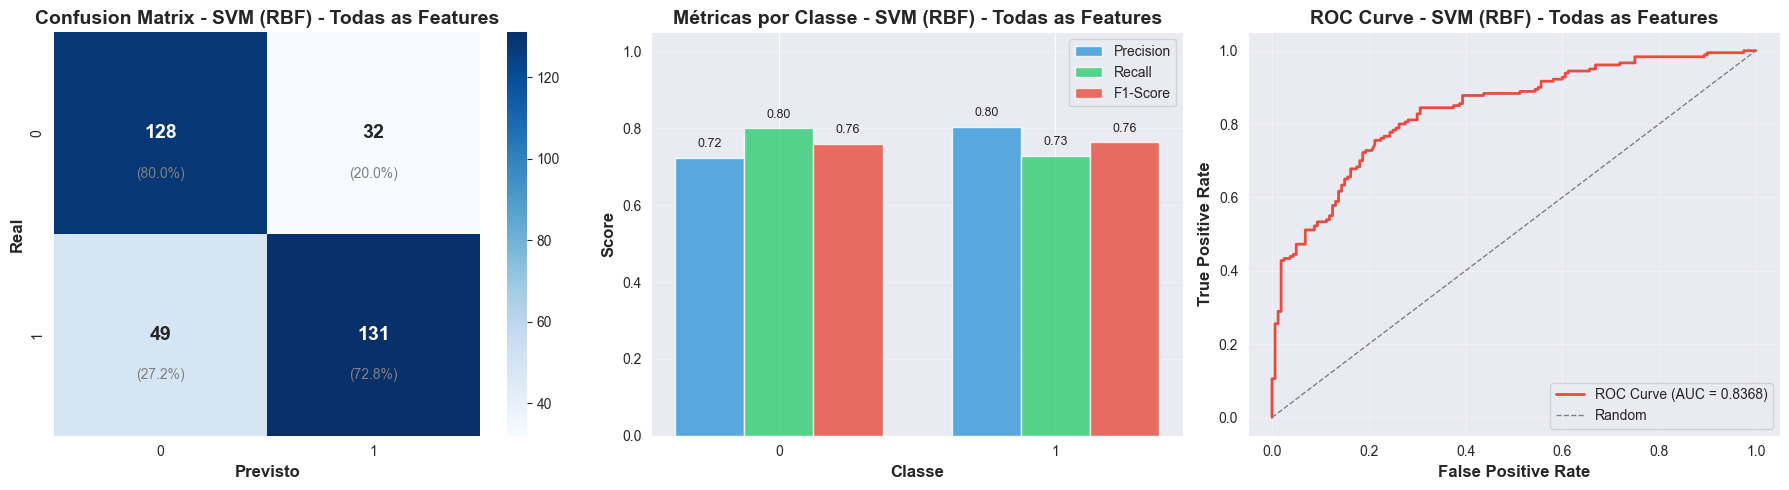


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 259 (76.18%)
   Erros: 81 (23.82%)

   Distribuição de Erros:
      Classe 0: 32/160 (20.0% de erro)
      Classe 1: 49/180 (27.2% de erro)



In [133]:

svm_clf.fit(X_train_scaled, y_train)

metricas_svm = avaliar_modelo(
    modelo=svm_clf,
    X_test=X_test_scaled,
    y_test=y_test,
    nome_modelo="SVM (RBF) - Todas as Features"
)


# 8. Seleção  de Features

## 8.1 Importância das Features (Random Forest)

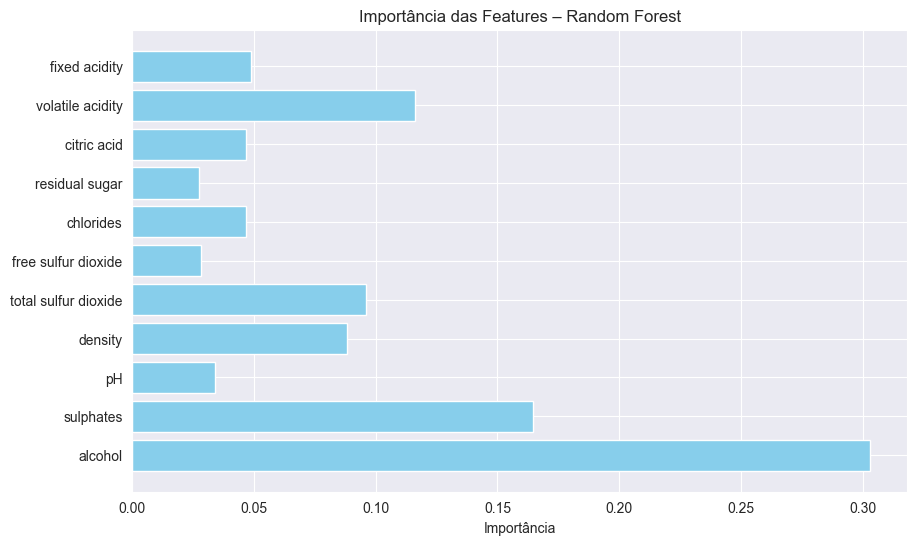

In [134]:
feature_importances = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel("Importância")
plt.title("Importância das Features – Random Forest")
plt.gca().invert_yaxis()
plt.show()

## 8.2 Mutual Information

=== Mutual Information Ranking ===
                 Feature  MI Score
10               alcohol  0.121199
9              sulphates  0.083922
1       volatile acidity  0.054853
6   total sulfur dioxide  0.038169
7                density  0.023337
3         residual sugar  0.015462
4              chlorides  0.012903
8                     pH  0.010867
0          fixed acidity  0.009165
2            citric acid  0.007717
5    free sulfur dioxide  0.000000


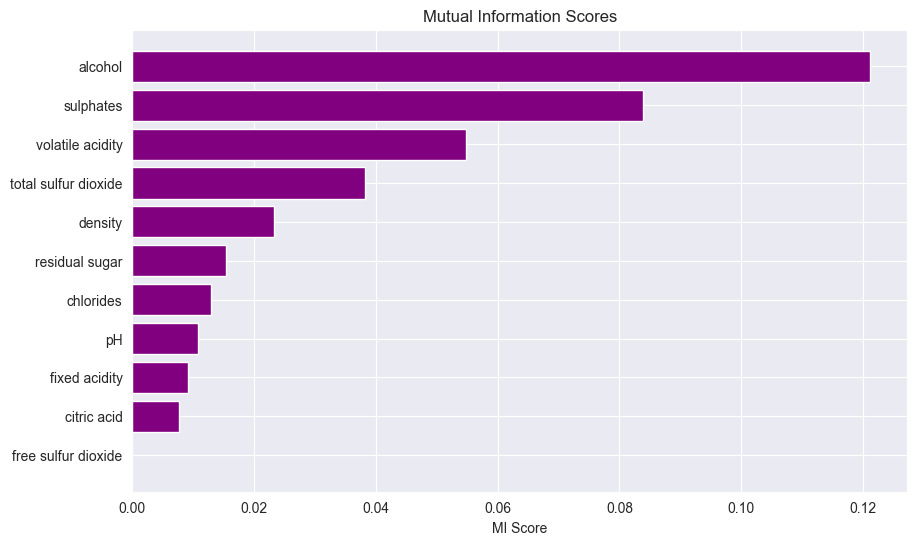

In [135]:

# Mutual Information (usa dados NÃO normalizados)
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("=== Mutual Information Ranking ===")
print(mi_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='purple')
plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.gca().invert_yaxis()
plt.show()


## 8.3 Permutation Importance (Neural Network)

=== Permutation Importance (NN) ===
                 Feature  Importance
10               alcohol    0.132353
9              sulphates    0.065294
6   total sulfur dioxide    0.039412
1       volatile acidity    0.028824
7                density    0.017451
2            citric acid    0.017255
5    free sulfur dioxide    0.015686
8                     pH    0.012745
4              chlorides    0.009608
0          fixed acidity    0.007255
3         residual sugar    0.004902


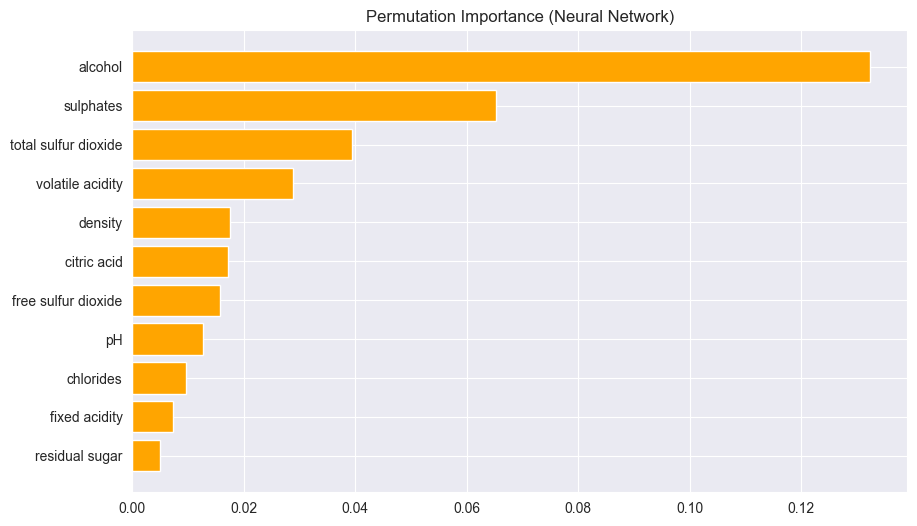

In [136]:

perm_result = permutation_importance(
    best_mlp,  # a tua neural network treinada
    X_test_scaled,
    y_test,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

print("=== Permutation Importance (NN) ===")
print(perm_df)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'], color='orange')
plt.title("Permutation Importance (Neural Network)")
plt.gca().invert_yaxis()
plt.show()


# 9. Remoção de Features Fracas

## 9.1 Criação de Dataset Reduzido

In [137]:
## Remover features fracas: citric acid, chlorides, free sulfur dioxide

features_to_drop = ['citric acid', 'chlorides', 'free sulfur dioxide']

wine_data_reduced = wine_data_bi.drop(columns=features_to_drop)

wine_data_reduced.head()


,fixed acidity,volatile acidity,residual sugar,total sulfur dioxide,density,pH,sulphates,alcohol,Target
0,7.4,0.70,1.9,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,2.6,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,2.3,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,1.9,60.0,0.9980,3.16,0.58,9.8,1
5,7.4,0.66,1.8,40.0,0.9978,3.51,0.56,9.4,0


In [138]:
## Separar X e y para o dataset reduzido
X_red = wine_data_reduced.drop(columns=['Target'])
y_red = wine_data_reduced['Target']

## Train/Test Split (dataset reduzido)

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red,
    y_red,
    test_size=0.25,
    random_state=42,
    stratify=y_red
)

## Normalização (apenas com dados reduzidos)

scaler_red = StandardScaler()
X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)


## 9.2 Avaliação Neural Network (Reduced)

In [139]:
params_mlp = {
    'activation': 'tanh',
    'alpha': 0.05,
    'hidden_layer_sizes': (64,),
    'learning_rate': 'constant',
    'learning_rate_init': 0.01,
    'max_iter': 2500,
    'solver': 'sgd'
}

best_mlp, mlp_accs = ensemble_mlp_full(
    X_train_red_scaled,
    X_test_red_scaled,
    y_train_red,
    y_test_red,
    params_mlp
)


 TREINAR 30 MODELOS MLP (Neural Network)

Modelo 01/30 -> Test Accuracy: 0.7441
Modelo 02/30 -> Test Accuracy: 0.7559
Modelo 03/30 -> Test Accuracy: 0.7647
Modelo 04/30 -> Test Accuracy: 0.7559
Modelo 05/30 -> Test Accuracy: 0.7588
Modelo 06/30 -> Test Accuracy: 0.7559
Modelo 07/30 -> Test Accuracy: 0.7559
Modelo 08/30 -> Test Accuracy: 0.7559
Modelo 09/30 -> Test Accuracy: 0.7471
Modelo 10/30 -> Test Accuracy: 0.7529
Modelo 11/30 -> Test Accuracy: 0.7647
Modelo 12/30 -> Test Accuracy: 0.7441
Modelo 13/30 -> Test Accuracy: 0.7500
Modelo 14/30 -> Test Accuracy: 0.7529
Modelo 15/30 -> Test Accuracy: 0.7471
Modelo 16/30 -> Test Accuracy: 0.7735
Modelo 17/30 -> Test Accuracy: 0.7647
Modelo 18/30 -> Test Accuracy: 0.7676
Modelo 19/30 -> Test Accuracy: 0.7676
Modelo 20/30 -> Test Accuracy: 0.7412
Modelo 21/30 -> Test Accuracy: 0.7471
Modelo 22/30 -> Test Accuracy: 0.7618
Modelo 23/30 -> Test Accuracy: 0.7441
Modelo 24/30 -> Test Accuracy: 0.7529
Modelo 25/30 -> Test Accuracy: 0.7529
Modelo 

## 9.3 Avaliação Random Forest (Reduced)

In [178]:
rf_params = {
    'bootstrap': True,
    'max_depth': 5,
    'min_samples_leaf': 1,
    'min_samples_split': 5,
    'n_estimators': 200
}

best_rf, accs = ensemble_rf_full(
    X_train_red_scaled, X_test_red_scaled,
    y_train_red, y_test_red,
    rf_params
)



 TREINAR 30 MODELOS RANDOM FOREST

Modelo 01/30 -> Test Accuracy: 0.7735
Modelo 02/30 -> Test Accuracy: 0.7765
Modelo 03/30 -> Test Accuracy: 0.7735
Modelo 04/30 -> Test Accuracy: 0.7765
Modelo 05/30 -> Test Accuracy: 0.7765
Modelo 06/30 -> Test Accuracy: 0.7765
Modelo 07/30 -> Test Accuracy: 0.7735
Modelo 08/30 -> Test Accuracy: 0.7647
Modelo 09/30 -> Test Accuracy: 0.7735
Modelo 10/30 -> Test Accuracy: 0.7794
Modelo 11/30 -> Test Accuracy: 0.7882
Modelo 12/30 -> Test Accuracy: 0.7853
Modelo 13/30 -> Test Accuracy: 0.7882
Modelo 14/30 -> Test Accuracy: 0.7765
Modelo 15/30 -> Test Accuracy: 0.7735
Modelo 16/30 -> Test Accuracy: 0.7824
Modelo 17/30 -> Test Accuracy: 0.7794
Modelo 18/30 -> Test Accuracy: 0.7794
Modelo 19/30 -> Test Accuracy: 0.7765
Modelo 20/30 -> Test Accuracy: 0.7794
Modelo 21/30 -> Test Accuracy: 0.7676
Modelo 22/30 -> Test Accuracy: 0.7765
Modelo 23/30 -> Test Accuracy: 0.7765
Modelo 24/30 -> Test Accuracy: 0.7676
Modelo 25/30 -> Test Accuracy: 0.7853
Modelo 26/30 -

## 9.4 Avaliação SVM (Reduced)

In [141]:
## TREINAR SVM (SEM FEATURES FRACAS)




# Modelo SVM (dataset reduzido)
svm_red = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,          # incluído para corresponder ao modelo escolhido (é ignorado pelo RBF)
    probability=True,
    random_state=42
)


# Treinar com dados reduzidos (normalizados)
svm_red.fit(X_train_red_scaled, y_train_red)

# Prever
svm_red_preds = svm_red.predict(X_test_red_scaled)

# Métricas
print("=== SVM (Reduced Features) ===")
print(classification_report(y_test_red, svm_red_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test_red, svm_red_preds))

svm_acc_red = accuracy_score(y_test_red, svm_red_preds)
svm_prec_red = precision_score(y_test_red, svm_red_preds)
svm_rec_red = recall_score(y_test_red, svm_red_preds)
svm_f1_red = f1_score(y_test_red, svm_red_preds)

print(f"Accuracy:  {svm_acc_red:.4f}")
print(f"Precision: {svm_prec_red:.4f}")
print(f"Recall:    {svm_rec_red:.4f}")
print(f"F1 Score:  {svm_f1_red:.4f}")


=== SVM (Reduced Features) ===
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       160
           1       0.82      0.74      0.78       180

    accuracy                           0.77       340
   macro avg       0.78      0.78      0.77       340
weighted avg       0.78      0.77      0.77       340

Confusion Matrix:
 [[130  30]
 [ 47 133]]
Accuracy:  0.7735
Precision: 0.8160
Recall:    0.7389
F1 Score:  0.7755


# 10. Feature Engineering

In [142]:
## FEATURE ENGINEERING

df_fe = wine_data_bi.copy()  # criar uma cópia para engenieria de features

# 1. Relação de dióxidos de enxofre
df_fe['SO2_ratio'] = df_fe['free sulfur dioxide'] / (df_fe['total sulfur dioxide'] + 1e-6)

# 2. Acidity index (acidez relativa ao pH)
df_fe['acidity_index'] = df_fe['fixed acidity'] / (df_fe['pH'] + 1e-6)

# 3. Relação álcool - densidade
df_fe['alc_density_diff'] = df_fe['alcohol'] - df_fe['density']

# 4. Total acidity (soma de acidezes)
df_fe['total_acidity'] = (
        df_fe['fixed acidity'] +
        df_fe['volatile acidity'] +
        df_fe['citric acid']
)

# 5. Normalizar sulfatos pelo álcool
df_fe['sulphates_per_alc'] = df_fe['sulphates'] / (df_fe['alcohol'] + 1e-6)

# 6. Log transforms para colunas com long tail
for col in ['residual sugar', 'chlorides', 'sulphates', 'total sulfur dioxide']:
    df_fe[f'log_{col.replace(" ", "_")}'] = np.log1p(df_fe[col])

df_fe.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,Target,SO2_ratio,acidity_index,alc_density_diff,total_acidity,sulphates_per_alc,log_residual_sugar,log_chlorides,log_sulphates,log_total_sulfur_dioxide
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,0,0.323529,2.108262,8.4022,8.10,0.059574,1.064711,0.073250,0.444686,3.555348
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,...,0,0.373134,2.437499,8.8032,8.68,0.069388,1.280934,0.093490,0.518794,4.219508
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,...,0,0.277778,2.392637,8.8030,8.60,0.066327,1.193922,0.088011,0.500775,4.007333
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,...,1,0.283333,3.544303,8.8020,12.04,0.059184,1.064711,0.072321,0.457425,4.110874
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,...,0,0.325000,2.108262,8.4022,8.06,0.059574,1.029619,0.072321,0.444686,3.713572


## 10.1 Neural Network com Feature Engineering

 DIAGNÓSTICO: Neural Network - Feature Engineering

1️ PERFORMANCE:
   Accuracy TREINO: 0.8724 (87.24%)
   Accuracy TESTE:  0.7265 (72.65%)
   Gap (diferença): 0.1460 (14.60%)

2️ CONVERGÊNCIA:
   Iterações usadas: 833 / 2500
    Modelo convergiu antes do limite
   Loss final: 0.328096
    Loss estabilizado (std=0.0009)

3️ DIAGNÓSTICO:
     OVERFITTING MODERADO
    Há algum overfitting (gap = 0.1460)

     AÇÕES RECOMENDADAS:
      1. Aumentar alpha de 0.0001 para 0.001 ou 0.005
      2. Usar early_stopping=True
      3. Adicionar mais dados (se possível)



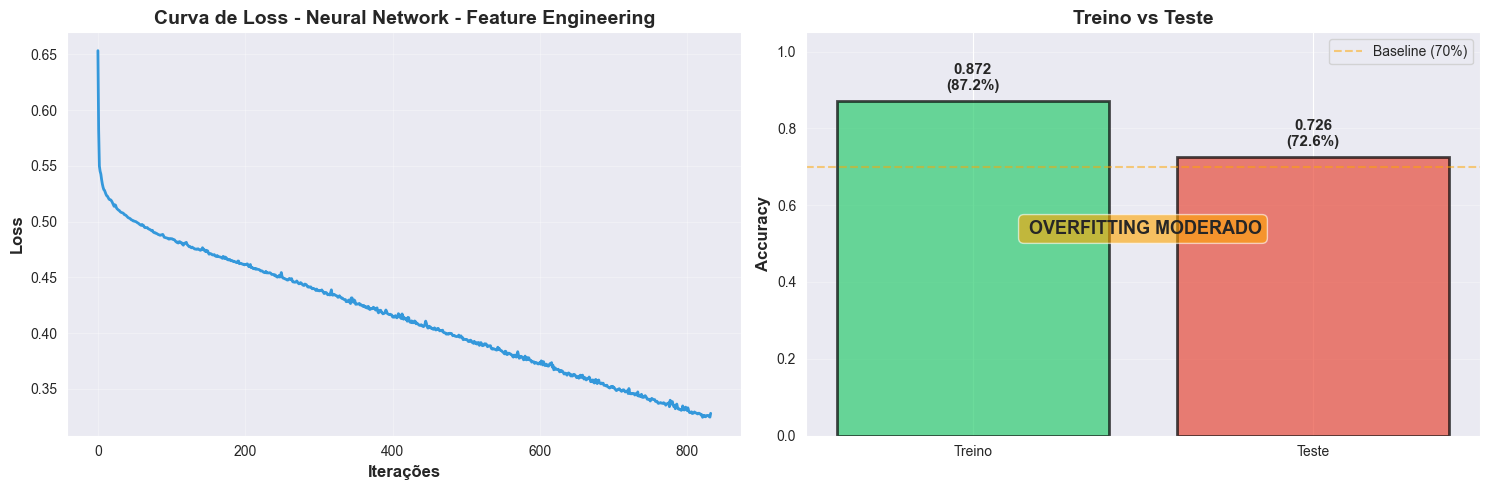

=== Neural Network (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       160
           1       0.77      0.68      0.73       180

    accuracy                           0.73       340
   macro avg       0.73      0.73      0.73       340
weighted avg       0.73      0.73      0.73       340

Confusion Matrix:
 [[124  36]
 [ 57 123]]

Accuracy : 0.7265
Precision: 0.7736
Recall   : 0.6833
F1 Score : 0.7257


In [143]:
## Separar X e y (dataset com feature engineering)
X_fe = df_fe.drop(columns=['Target'])
y_fe = df_fe['Target']

## Train/Test Split

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.25,
    random_state=42,
    stratify=y_fe
)

## Normalização para NN

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

## Neural Network (com feature engineering)


nn_fe = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='tanh',
    solver='sgd',
    alpha=0.05,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=42
)

# Treinar
nn_fe.fit(X_train_fe_scaled, y_train_fe)

resultados_nn_fe = diagnosticar_neural_network(
    modelo=nn_fe,
    X_train=X_train_fe_scaled,
    X_test=X_test_fe_scaled,
    y_train=y_train_fe,
    y_test=y_test_fe,
    nome_modelo="Neural Network - Feature Engineering"
)

# Previsões
nn_preds_fe = nn_fe.predict(X_test_fe_scaled)

print("=== Neural Network (Feature Engineering) ===")
print(classification_report(y_test_fe, nn_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, nn_preds_fe))

nn_acc = accuracy_score(y_test_fe, nn_preds_fe)
nn_prec = precision_score(y_test_fe, nn_preds_fe)
nn_rec = recall_score(y_test_fe, nn_preds_fe)
nn_f1 = f1_score(y_test_fe, nn_preds_fe)

print(f"\nAccuracy : {nn_acc:.4f}")
print(f"Precision: {nn_prec:.4f}")
print(f"Recall   : {nn_rec:.4f}")
print(f"F1 Score : {nn_f1:.4f}")


## 10.2 Random Forest com Feature Engineering

In [144]:
## Random Forest (com feature engineering)

rf_fe = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)

# Treinar
rf_fe.fit(X_train_fe, y_train_fe)

# Previsões
rf_preds_fe = rf_fe.predict(X_test_fe)

print("=== Random Forest (Feature Engineering) ===")
print(classification_report(y_test_fe, rf_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, rf_preds_fe))

rf_acc = accuracy_score(y_test_fe, rf_preds_fe)
rf_prec = precision_score(y_test_fe, rf_preds_fe)
rf_rec = recall_score(y_test_fe, rf_preds_fe)
rf_f1 = f1_score(y_test_fe, rf_preds_fe)

print(f"\nAccuracy : {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall   : {rf_rec:.4f}")
print(f"F1 Score : {rf_f1:.4f}")


=== Random Forest (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       160
           1       0.79      0.73      0.76       180

    accuracy                           0.76       340
   macro avg       0.76      0.76      0.76       340
weighted avg       0.76      0.76      0.76       340

Confusion Matrix:
 [[125  35]
 [ 48 132]]

Accuracy : 0.7559
Precision: 0.7904
Recall   : 0.7333
F1 Score : 0.7608


## 10.3 SVM com Feature Engineering

In [145]:
#SVM com Feature Engineering



# Criar modelo SVM (com engineered features)
svm_fe = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,
    probability=True,
    random_state=42
)

# Treinar (usar dados normalizados)
svm_fe.fit(X_train_fe_scaled, y_train_fe)

# Prever
svm_preds_fe = svm_fe.predict(X_test_fe_scaled)

print("=== SVM (Feature Engineering) ===")
print(classification_report(y_test_fe, svm_preds_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test_fe, svm_preds_fe))

svm_acc_fe = accuracy_score(y_test_fe, svm_preds_fe)
svm_prec_fe = precision_score(y_test_fe, svm_preds_fe)
svm_rec_fe = recall_score(y_test_fe, svm_preds_fe)
svm_f1_fe = f1_score(y_test_fe, svm_preds_fe)

print(f"\nAccuracy : {svm_acc_fe:.4f}")
print(f"Precision: {svm_prec_fe:.4f}")
print(f"Recall   : {svm_rec_fe:.4f}")
print(f"F1 Score : {svm_f1_fe:.4f}")


=== SVM (Feature Engineering) ===
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       160
           1       0.79      0.72      0.75       180

    accuracy                           0.75       340
   macro avg       0.75      0.75      0.75       340
weighted avg       0.75      0.75      0.75       340

Confusion Matrix:
 [[125  35]
 [ 51 129]]

Accuracy : 0.7471
Precision: 0.7866
Recall   : 0.7167
F1 Score : 0.7500


## 10.4 Mutual Information com FE

=== MUTUAL INFORMATION (Feature Engineering) ===
                     Feature  MI Score
10                   alcohol  0.140360
13          alc_density_diff  0.131559
18             log_sulphates  0.075196
1           volatile acidity  0.062316
15         sulphates_per_alc  0.055709
9                  sulphates  0.051473
6       total sulfur dioxide  0.048742
19  log_total_sulfur_dioxide  0.040029
11                 SO2_ratio  0.038236
5        free sulfur dioxide  0.033255
4                  chlorides  0.031395
7                    density  0.019032
0              fixed acidity  0.017237
12             acidity_index  0.012697
3             residual sugar  0.008812
14             total_acidity  0.005170
8                         pH  0.002387
17             log_chlorides  0.000555
2                citric acid  0.000000
16        log_residual_sugar  0.000000


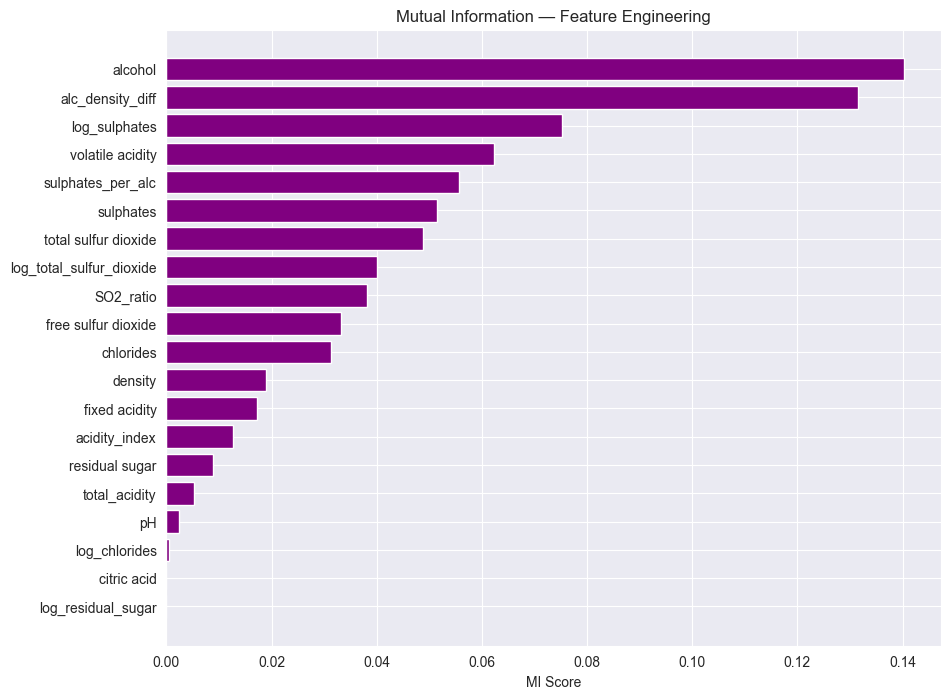

In [146]:
## MUTUAL INFORMATION — Feature Engineering


# Calcular MI
mi_scores_fe = mutual_info_classif(X_fe, y_fe, random_state=42)

# Criar DataFrame ordenado
mi_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'MI Score': mi_scores_fe
}).sort_values(by="MI Score", ascending=False)

print("=== MUTUAL INFORMATION (Feature Engineering) ===")
print(mi_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(mi_df_fe['Feature'], mi_df_fe['MI Score'], color='purple')
plt.gca().invert_yaxis()
plt.title("Mutual Information — Feature Engineering")
plt.xlabel("MI Score")
plt.show()


## 10.5 Random Forest Feature Importance com FE

=== RANDOM FOREST IMPORTANCE (Feature Engineering) ===
                     Feature  Importance
13          alc_density_diff    0.205688
10                   alcohol    0.161295
9                  sulphates    0.084524
18             log_sulphates    0.073029
1           volatile acidity    0.067978
19  log_total_sulfur_dioxide    0.046237
6       total sulfur dioxide    0.043670
15         sulphates_per_alc    0.039048
7                    density    0.038020
11                 SO2_ratio    0.033244
12             acidity_index    0.028985
17             log_chlorides    0.024800
2                citric acid    0.024614
0              fixed acidity    0.023769
4                  chlorides    0.022438
8                         pH    0.020046
5        free sulfur dioxide    0.019055
14             total_acidity    0.018918
16        log_residual_sugar    0.012340
3             residual sugar    0.012302


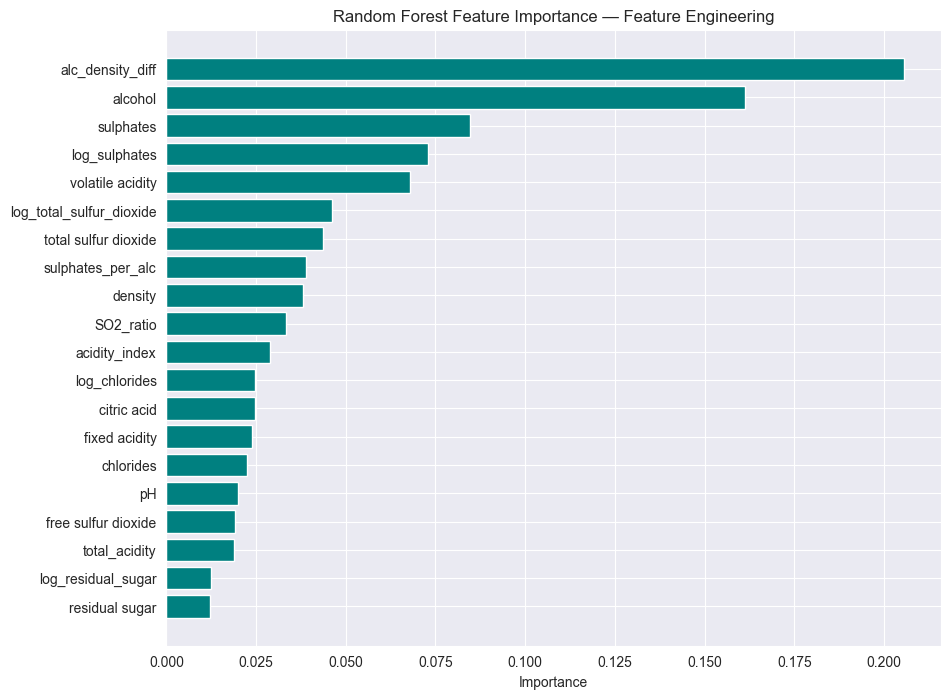

In [147]:
## RANDOM FOREST FEATURE IMPORTANCE — Feature Engineering



# Criar e treinar o modelo
rf_fe_fs = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)

rf_fe_fs.fit(X_train_fe, y_train_fe)

# Importâncias
rf_importances_fe = rf_fe_fs.feature_importances_

# DataFrame ordenado
rf_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': rf_importances_fe
}).sort_values(by='Importance', ascending=False)

print("=== RANDOM FOREST IMPORTANCE (Feature Engineering) ===")
print(rf_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(rf_df_fe['Feature'], rf_df_fe['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance — Feature Engineering")
plt.xlabel("Importance")
plt.show()


## 10.6 Permutation Importance com FE

=== PERMUTATION IMPORTANCE (Feature Engineering) ===
                     Feature  Importance
6       total sulfur dioxide    0.096078
13          alc_density_diff    0.059216
10                   alcohol    0.056471
1           volatile acidity    0.036863
16        log_residual_sugar    0.035490
19  log_total_sulfur_dioxide    0.030392
2                citric acid    0.028235
12             acidity_index    0.026275
18             log_sulphates    0.025882
3             residual sugar    0.021765
11                 SO2_ratio    0.016863
15         sulphates_per_alc    0.014510
7                    density    0.013725
0              fixed acidity    0.013529
5        free sulfur dioxide    0.010980
9                  sulphates    0.006863
14             total_acidity    0.005686
8                         pH    0.005098
4                  chlorides    0.003529
17             log_chlorides   -0.000784


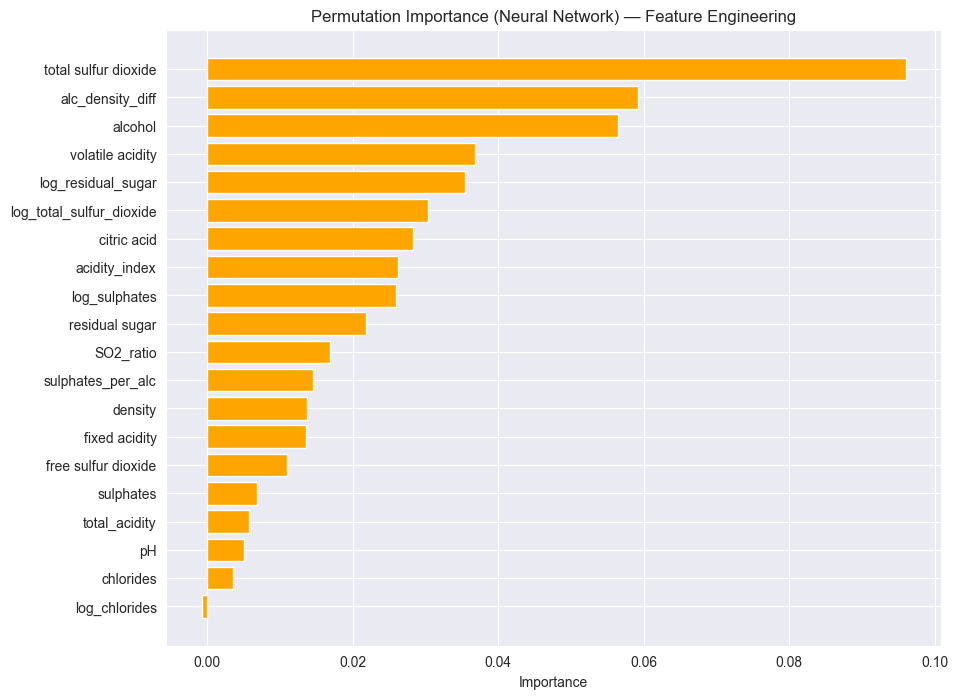

In [148]:
## PERMUTATION IMPORTANCE (NN) — Feature Engineering


# Calcular Permutation Importance
perm_fe = permutation_importance(
    nn_fe,  # modelo NN treinado com FE
    X_test_fe_scaled,  # dados de teste normalizados com FE
    y_test_fe,  # labels
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

# Criar DF ordenado por importância
perm_df_fe = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': perm_fe.importances_mean
}).sort_values(by='Importance', ascending=False)

# Mostrar resultado
print("=== PERMUTATION IMPORTANCE (Feature Engineering) ===")
print(perm_df_fe)

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(perm_df_fe['Feature'], perm_df_fe['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Neural Network) — Feature Engineering")
plt.xlabel("Importance")
plt.show()


# 11. Feature Selection Final

## 11.1 Ranking via Voting (MI + RF + PI) e Seleção das Top 10 Features

In [149]:
## FEATURE SELECTION FINAL — TOP 10 com Voting (MI + RF + Permutation Importance)


# Top 10 de cada método
top_k = 10

mi_top10 = list(mi_df_fe.sort_values("MI Score", ascending=False).head(top_k)["Feature"])
rf_top10 = list(rf_df_fe.sort_values("Importance", ascending=False).head(top_k)["Feature"])
pi_top10 = list(perm_df_fe.sort_values("Importance", ascending=False).head(top_k)["Feature"])

print("MI TOP10:", mi_top10)
print("RF TOP10:", rf_top10)
print("PI TOP10:", pi_top10)

# Votação (Ensemble)
all_candidates = mi_top10 + rf_top10 + pi_top10

vote_count = pd.Series(all_candidates).value_counts()

# Features ordenadas pela quantidade de votos (3 → muito forte)
final_top10 = list(vote_count.head(10).index)

print("\n=== TOP 10 FEATURES SELECIONADAS ===")
for f in final_top10:
    print(" -", f)


MI TOP10: ['alcohol', 'alc_density_diff', 'log_sulphates', 'volatile acidity', 'sulphates_per_alc', 'sulphates', 'total sulfur dioxide', 'log_total_sulfur_dioxide', 'SO2_ratio', 'free sulfur dioxide']
RF TOP10: ['alc_density_diff', 'alcohol', 'sulphates', 'log_sulphates', 'volatile acidity', 'log_total_sulfur_dioxide', 'total sulfur dioxide', 'sulphates_per_alc', 'density', 'SO2_ratio']
PI TOP10: ['total sulfur dioxide', 'alc_density_diff', 'alcohol', 'volatile acidity', 'log_residual_sugar', 'log_total_sulfur_dioxide', 'citric acid', 'acidity_index', 'log_sulphates', 'residual sugar']

=== TOP 10 FEATURES SELECIONADAS ===
 - alcohol
 - alc_density_diff
 - log_sulphates
 - volatile acidity
 - total sulfur dioxide
 - log_total_sulfur_dioxide
 - sulphates_per_alc
 - sulphates
 - SO2_ratio
 - free sulfur dioxide


## 11.2 Dataset Final com top 10 features

In [150]:
# Dataset final com as TOP 10 features
X_final = df_fe[[
    'alcohol',
    'alc_density_diff',
    'log_sulphates',
    'volatile acidity',
    'sulphates',
    'log_total_sulfur_dioxide',
    'total sulfur dioxide',
    'sulphates_per_alc',
    'SO2_ratio',
    'free sulfur dioxide'
]]

y_final = df_fe['Target']


In [151]:


X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.25, random_state=42, stratify=y_final
)

# Normalização só para NN
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)


# 12. Modelos Finais com Top 10 Features

## 12.1 Neural Network Final top10

 DIAGNÓSTICO: Neural Network - Top 10 Features Final

1️ PERFORMANCE:
   Accuracy TREINO: 0.7537 (75.37%)
   Accuracy TESTE:  0.7676 (76.76%)
   Gap (diferença): -0.0140 (-1.40%)

2️ CONVERGÊNCIA:
   Iterações usadas: 125 / 2500
    Modelo convergiu antes do limite
   Loss final: 0.502679
    Loss estabilizado (std=0.0007)

3️ DIAGNÓSTICO:
    BOM AJUSTE
    Modelo bem equilibrado (gap = -0.0140)

     PRÓXIMOS PASSOS:
      1. Fazer Grid Search para fine-tuning
      2. Testar arquiteturas ligeiramente diferentes
      3. Validar com cross-validation



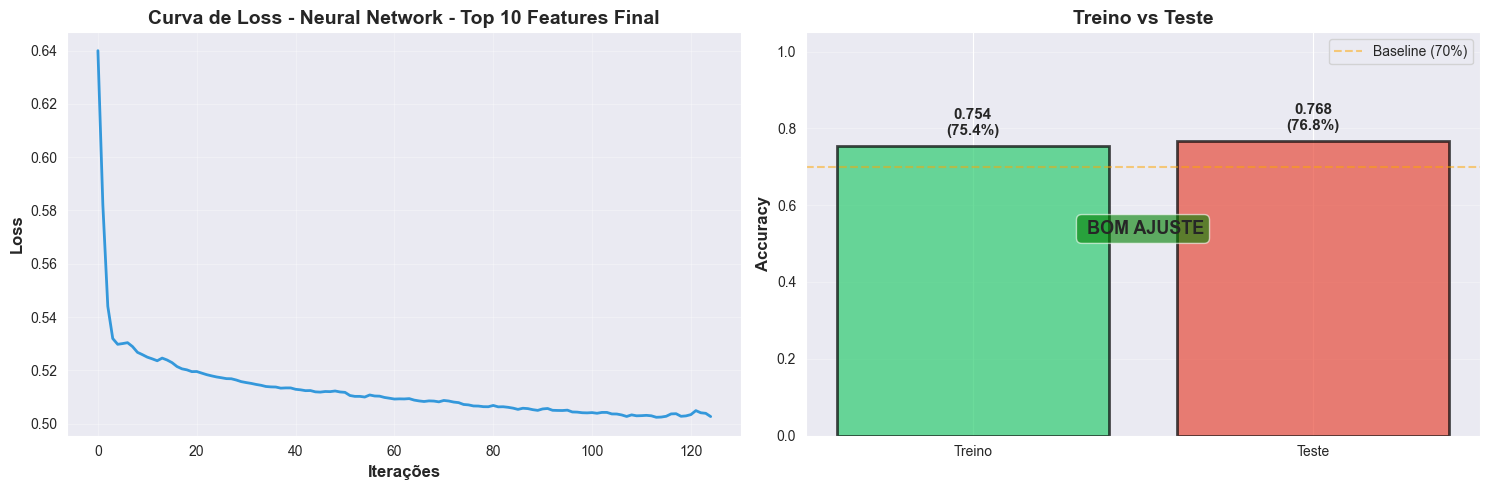

=== NEURAL NETWORK FINAL ===
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       160
           1       0.82      0.72      0.77       180

    accuracy                           0.77       340
   macro avg       0.77      0.77      0.77       340
weighted avg       0.77      0.77      0.77       340

[[131  29]
 [ 50 130]]


In [152]:
nn_final = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='tanh',
    solver='sgd',
    alpha=0.05,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=42
)

nn_final.fit(X_train_final_scaled, y_train_final)

resultados_nn_final = diagnosticar_neural_network(
    modelo=nn_final,
    X_train=X_train_final_scaled,
    X_test=X_test_final_scaled,
    y_train=y_train_final,
    y_test=y_test_final,
    nome_modelo="Neural Network - Top 10 Features Final"
)


nn_pred = nn_final.predict(X_test_final_scaled)

print("=== NEURAL NETWORK FINAL ===")
print(classification_report(y_test_final, nn_pred))
print(confusion_matrix(y_test_final, nn_pred))



## 12.2 Random Forest Final top10

In [153]:


rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)

rf_final.fit(X_train_final, y_train_final)
rf_pred = rf_final.predict(X_test_final)

print("=== RANDOM FOREST FINAL ===")
print(classification_report(y_test_final, rf_pred))
print(confusion_matrix(y_test_final, rf_pred))


=== RANDOM FOREST FINAL ===
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       160
           1       0.79      0.74      0.76       180

    accuracy                           0.76       340
   macro avg       0.76      0.76      0.76       340
weighted avg       0.76      0.76      0.76       340

[[124  36]
 [ 47 133]]


## 12.3 SVM Final top10

In [154]:


# Criar modelo SVM (Top 10 Features)
svm_final = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,
    probability=True,
    random_state=42
)

# Treinar (usar dados normalizados!)
svm_final.fit(X_train_final_scaled, y_train_final)

# Prever
svm_pred = svm_final.predict(X_test_final_scaled)

print("=== SVM FINAL (Top 10 Features) ===")
print(classification_report(y_test_final, svm_pred))
print(confusion_matrix(y_test_final, svm_pred))

# Métricas individuais (opcional)
svm_acc_final = accuracy_score(y_test_final, svm_pred)
svm_prec_final = precision_score(y_test_final, svm_pred)
svm_rec_final = recall_score(y_test_final, svm_pred)
svm_f1_final = f1_score(y_test_final, svm_pred)

print(f"\nAccuracy : {svm_acc_final:.4f}")
print(f"Precision: {svm_prec_final:.4f}")
print(f"Recall   : {svm_rec_final:.4f}")
print(f"F1 Score : {svm_f1_final:.4f}")


=== SVM FINAL (Top 10 Features) ===
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       160
           1       0.79      0.71      0.75       180

    accuracy                           0.74       340
   macro avg       0.75      0.75      0.74       340
weighted avg       0.75      0.74      0.74       340

[[125  35]
 [ 52 128]]

Accuracy : 0.7441
Precision: 0.7853
Recall   : 0.7111
F1 Score : 0.7464


# 13. Ranking Global das Features

In [155]:
# ======================================================
# RANKING COMPLETO DE FEATURES (MI + RF + PI)
# ======================================================

# 1. Mutual Information
mi_scores_all = mutual_info_classif(X_fe, y_fe, random_state=42)
mi_df_all = pd.DataFrame({'Feature': X_fe.columns, 'MI': mi_scores_all})

# 2. Random Forest Importance
rf_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42  )

rf_full.fit(X_fe, y_fe)
rf_importances_all = rf_full.feature_importances_
rf_df_all = pd.DataFrame({'Feature': X_fe.columns, 'RF': rf_importances_all})

# 3. Permutation Importance (NN)
perm_full = permutation_importance(
    nn_fe,
    X_test_fe_scaled,
    y_test_fe,
    n_repeats=10,
    random_state=42
)
pi_df_all = pd.DataFrame({'Feature': X_fe.columns, 'PI': perm_full.importances_mean})

# 4. Juntar tudo
ranking_full = (
    mi_df_all.merge(rf_df_all, on="Feature")
             .merge(pi_df_all, on="Feature")
)

# Normalizar cada coluna entre 0 e 1
for col in ["MI", "RF", "PI"]:
    ranking_full[col] = (ranking_full[col] - ranking_full[col].min()) / (ranking_full[col].max() - ranking_full[col].min())

# Score final = soma das importâncias normalizadas
ranking_full["Score"] = ranking_full["MI"] + ranking_full["RF"] + ranking_full["PI"]

# Ordenar da melhor para a pior
ranking_full = ranking_full.sort_values("Score", ascending=False).reset_index(drop=True)

# Ranking final (lista completa ordenada)
ranking_completo = list(ranking_full["Feature"])

print("=== RANKING COMPLETO (Top 30) ===")
print(ranking_completo[:30])


=== RANKING COMPLETO (Top 30) ===
['alc_density_diff', 'alcohol', 'total sulfur dioxide', 'log_sulphates', 'volatile acidity', 'sulphates', 'log_total_sulfur_dioxide', 'sulphates_per_alc', 'SO2_ratio', 'density', 'acidity_index', 'citric acid', 'free sulfur dioxide', 'log_residual_sugar', 'residual sugar', 'chlorides', 'fixed acidity', 'total_acidity', 'pH', 'log_chlorides']


# 14. Comparação por Top K Features

## 14.1 Teste com K = 8, 10, 12

In [156]:
def testar_top_k_ensemble_binario(df, target, ranking, topks=[8, 10, 12], n_runs=30):

    import numpy as np
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.neural_network import MLPClassifier
    from sklearn.svm import SVC
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    resultados = []

    # Função estatística detalhada
    def estatisticas_completas(v):
        v = np.array(v)
        mean = np.mean(v)
        std = np.std(v)
        se = std / np.sqrt(len(v))
        mediana = np.median(v)
        minimo = np.min(v)
        maximo = np.max(v)
        q1 = np.percentile(v, 25)
        q3 = np.percentile(v, 75)
        iqr = q3 - q1
        cv = (std / mean) * 100
        ic_low = mean - 1.96 * se
        ic_up = mean + 1.96 * se

        return {
            "mean": mean,
            "std": std,
            "se": se,
            "mediana": mediana,
            "min": minimo,
            "max": maximo,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "cv": cv,
            "ic_low": ic_low,
            "ic_up": ic_up
        }

    for k in topks:

        print(f"\n================================================")
        print(f"                  TESTAR TOP {k}")
        print("================================================")

        # --------------------------
        # PREPARAÇÃO DOS DADOS
        # --------------------------
        selected = ranking[:k]
        X = df[selected]
        y = df[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)


        # =====================================================
        #                RANDOM FOREST — 30 EXECUÇÕES
        # =====================================================
        print(f"\n---- RANDOM FOREST (Top {k}) ----")

        accs = []
        precs = []
        recs = []
        f1s = []

        for i in range(n_runs):

            rf = RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=42 + i
            )

            rf.fit(X_train_scaled, y_train)
            pred = rf.predict(X_test_scaled)

            accs.append(accuracy_score(y_test, pred))
            precs.append(precision_score(y_test, pred))
            recs.append(recall_score(y_test, pred))
            f1s.append(f1_score(y_test, pred))

            print(f"RF Run {i+1:02d}/{n_runs} → Acc={accs[-1]:.4f} F1={f1s[-1]:.4f}")

        stats = estatisticas_completas(accs)

        print("\n==========================================")
        print("     ESTATÍSTICAS DO ENSEMBLE (30 RF)")
        print("==========================================")
        print(f"   Média (μ):               {stats['mean']:.4f}")
        print(f"   Desvio Padrão (σ):       {stats['std']:.4f}")
        print(f"   Standard Error (SE):     {stats['se']:.4f}")
        print(f"   Mediana:                 {stats['mediana']:.4f}")
        print(f"   Mínimo:                  {stats['min']:.4f}")
        print(f"   Máximo:                  {stats['max']:.4f}")
        print(f"   Quartil 1 (Q1):          {stats['q1']:.4f}")
        print(f"   Quartil 3 (Q3):          {stats['q3']:.4f}")
        print(f"   IQR (Q3 - Q1):           {stats['iqr']:.4f}")
        print(f"   Coef. Variação (CV):     {stats['cv']:.2f}%")
        print("\nINTERVALO DE CONFIANÇA (95%):")
        print(f"   [{stats['ic_low']:.4f}, {stats['ic_up']:.4f}]")

        resultados.append([
            "RandomForest", k,
            stats["mean"], stats["std"], stats["ic_low"], stats["ic_up"],
            np.mean(precs), np.mean(recs), np.mean(f1s)
        ])


        # =====================================================
        #            NEURAL NETWORK — 30 EXECUÇÕES
        # =====================================================
        print(f"\n---- NEURAL NETWORK (Top {k}) ----")

        accs = []
        precs = []
        recs = []
        f1s = []

        for i in range(n_runs):

            nn = MLPClassifier(
                hidden_layer_sizes=(64,),
                activation='tanh',
                solver='sgd',
                alpha=0.05,
                learning_rate='constant',
                learning_rate_init=0.01,
                max_iter=2500,
                random_state=42 + i
            )

            nn.fit(X_train_scaled, y_train)
            pred = nn.predict(X_test_scaled)

            accs.append(accuracy_score(y_test, pred))
            precs.append(precision_score(y_test, pred))
            recs.append(recall_score(y_test, pred))
            f1s.append(f1_score(y_test, pred))

            print(f"NN Run {i+1:02d}/{n_runs} → Acc={accs[-1]:.4f} F1={f1s[-1]:.4f}")

        stats = estatisticas_completas(accs)

        print("\n==============================================")
        print("     ESTATÍSTICAS DO ENSEMBLE (30 NN)")
        print("==============================================")
        print(f"   Média (μ):               {stats['mean']:.4f}")
        print(f"   Desvio Padrão (σ):       {stats['std']:.4f}")
        print(f"   SE:                      {stats['se']:.4f}")
        print(f"   Mediana:                 {stats['mediana']:.4f}")
        print(f"   Min:                     {stats['min']:.4f}")
        print(f"   Max:                     {stats['max']:.4f}")
        print(f"   Q1:                      {stats['q1']:.4f}")
        print(f"   Q3:                      {stats['q3']:.4f}")
        print(f"   IQR:                     {stats['iqr']:.4f}")
        print(f"   CV:                      {stats['cv']:.2f}%")
        print("\nINTERVALO DE CONFIANÇA (95%):")
        print(f"   [{stats['ic_low']:.4f}, {stats['ic_up']:.4f}]")

        resultados.append([
            "NeuralNetwork", k,
            stats["mean"], stats["std"], stats["ic_low"], stats["ic_up"],
            np.mean(precs), np.mean(recs), np.mean(f1s)
        ])


        # =====================================================
        #                     SVM — 1 EXECUÇÃO
        # =====================================================
        print(f"\n---- SVM (Top {k}) ----")

        svm = SVC(
            kernel='rbf',
            C=1,
            gamma='scale',
            degree=2,
            probability=True,
            random_state=42
        )

        svm.fit(X_train_scaled, y_train)
        pred = svm.predict(X_test_scaled)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred)
        rec = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred)

        print(f"SVM → Acc={acc:.4f} | F1={f1:.4f}")

        resultados.append([
            "SVM", k,
            acc, 0, 0, 0,
            prec, rec, f1
        ])

    # --------------------------
    # TABELA FINAL (como antes)
    # --------------------------
    df_result = pd.DataFrame(resultados, columns=[
        "Modelo", "TopK",
        "Accuracy", "Std", "IC_low", "IC_up",
        "Precision", "Recall", "F1"
    ])

    df_result["Modelo"] = pd.Categorical(df_result["Modelo"],
        categories=["RandomForest", "NeuralNetwork", "SVM"], ordered=True)

    return df_result.sort_values(["Modelo", "TopK"]).reset_index(drop=True)


In [157]:
df_binario_topk_ensemble = testar_top_k_ensemble_binario(
    df=df_fe,
    target="Target",
    ranking=ranking_completo
)

df_binario_topk_ensemble



                  TESTAR TOP 8

---- RANDOM FOREST (Top 8) ----
RF Run 01/30 → Acc=0.7471 F1=0.7543
RF Run 02/30 → Acc=0.7471 F1=0.7543
RF Run 03/30 → Acc=0.7441 F1=0.7521
RF Run 04/30 → Acc=0.7471 F1=0.7543
RF Run 05/30 → Acc=0.7500 F1=0.7564
RF Run 06/30 → Acc=0.7471 F1=0.7557
RF Run 07/30 → Acc=0.7500 F1=0.7564
RF Run 08/30 → Acc=0.7471 F1=0.7543
RF Run 09/30 → Acc=0.7471 F1=0.7557
RF Run 10/30 → Acc=0.7529 F1=0.7586
RF Run 11/30 → Acc=0.7500 F1=0.7578
RF Run 12/30 → Acc=0.7500 F1=0.7592
RF Run 13/30 → Acc=0.7500 F1=0.7592
RF Run 14/30 → Acc=0.7412 F1=0.7500
RF Run 15/30 → Acc=0.7471 F1=0.7557
RF Run 16/30 → Acc=0.7471 F1=0.7557
RF Run 17/30 → Acc=0.7559 F1=0.7622
RF Run 18/30 → Acc=0.7500 F1=0.7578
RF Run 19/30 → Acc=0.7471 F1=0.7543
RF Run 20/30 → Acc=0.7529 F1=0.7614
RF Run 21/30 → Acc=0.7441 F1=0.7507
RF Run 22/30 → Acc=0.7559 F1=0.7635
RF Run 23/30 → Acc=0.7529 F1=0.7600
RF Run 24/30 → Acc=0.7471 F1=0.7543
RF Run 25/30 → Acc=0.7529 F1=0.7614
RF Run 26/30 → Acc=0.7471 F1=0.7557

,Modelo,TopK,Accuracy,Std,IC_low,IC_up,Precision,Recall,F1
0,RandomForest,8,0.748725,0.003454,0.747490,0.749961,0.777238,0.736481,0.756298
1,RandomForest,10,0.761373,0.005355,0.759456,0.763289,0.791853,0.745185,0.767798
2,RandomForest,12,0.767549,0.005396,0.765618,0.769480,0.805511,0.739630,0.771123
3,NeuralNetwork,8,0.764314,0.009598,0.760879,0.767748,0.802714,0.735741,0.767634
4,NeuralNetwork,10,0.762647,0.006883,0.760184,0.765110,0.803365,0.730556,0.765119
5,NeuralNetwork,12,0.746961,0.011429,0.742871,0.751050,0.789227,0.712593,0.748738
6,SVM,8,0.750000,0.000000,0.000000,0.000000,0.787879,0.722222,0.753623
7,SVM,10,0.764706,0.000000,0.000000,0.000000,0.801205,0.738889,0.768786
8,SVM,12,0.741176,0.000000,0.000000,0.000000,0.787500,0.700000,0.741176


# 15. Classificação Multiclasse

## 15.1 Preparação dos Dados

In [158]:
wine_multi = wine_data.copy()       # já tens o wine_data carregado acima
X_multi = wine_multi.drop(columns=["quality"])
y_multi = wine_multi["quality"]

- Train Test Split (SEM SMOTE


In [159]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi,
    test_size=0.25,
    random_state=42,
    stratify=y_multi
)

## 15.2 Aplicação de SMOTE Multiclasse

In [160]:


smote = SMOTE(random_state=42, k_neighbors=2)

X_train_m_res, y_train_m_res = smote.fit_resample(X_train_m, y_train_m)

- Ver classe antes e depois do SMOTE


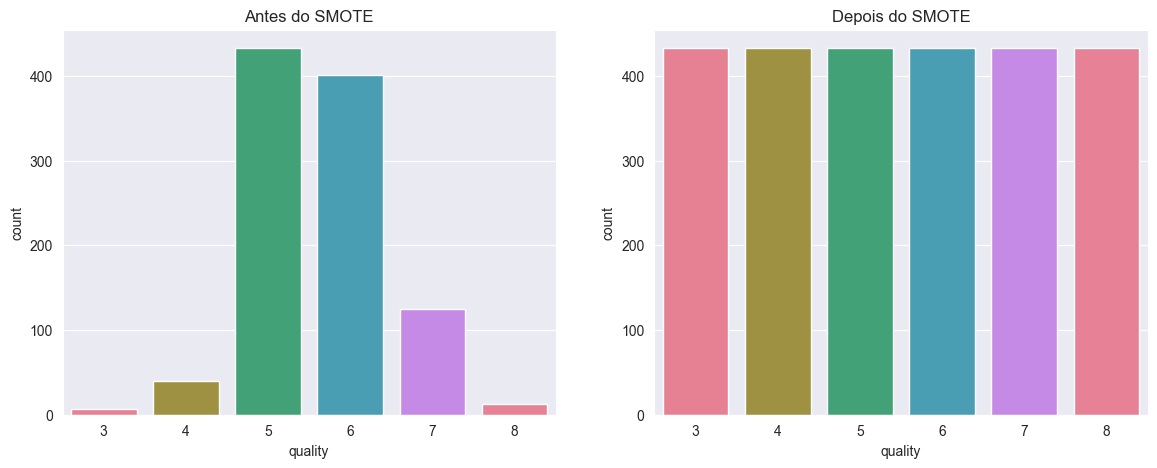

,Classe,Antes do SMOTE,Depois do SMOTE
0,3,7,433
1,4,40,433
2,5,433,433
3,6,401,433
4,7,125,433
5,8,13,433


In [161]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.countplot(x=y_train_m, hue=y_train_m, dodge=False, ax=ax[0], palette="husl", legend=False)
ax[0].set_title("Antes do SMOTE")

sns.countplot(x=y_train_m_res, hue=y_train_m_res, dodge=False, ax=ax[1], palette="husl", legend=False)
ax[1].set_title("Depois do SMOTE")

plt.show()


# Contagem ANTES
counts_before = y_train_m.value_counts().sort_index()

# Contagem DEPOIS (SMOTE)
counts_after = y_train_m_res.value_counts().sort_index()

# Criar tabela
df_counts = pd.DataFrame({
    "Classe": counts_before.index,
    "Antes do SMOTE": counts_before.values,
    "Depois do SMOTE": counts_after.values
})

df_counts

## 15.3 Normalização

In [162]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m_res)
X_test_m_scaled = scaler_m.transform(X_test_m)

## 15.4 Neural Network Multiclasse

In [163]:
nn_multi = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='tanh',
    solver='sgd',
    alpha=0.05,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=42
)

nn_multi.fit(X_train_m_scaled, y_train_m_res)
nn_pred = nn_multi.predict(X_test_m_scaled)

## 15.5 Random Forest Multiclasse

In [164]:
rf_multi_norm = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)

# Treinar com os dados normalizados (igual NN e SVM)
rf_multi_norm.fit(X_train_m_scaled, y_train_m_res)

# Prever
rf_multi_norm_pred = rf_multi_norm.predict(X_test_m_scaled)



## 15.6 SVM Multiclasse

In [165]:
svm_multi = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,
    probability=True,
    random_state=42

)

svm_multi.fit(X_train_m_scaled, y_train_m_res)
svm_pred = svm_multi.predict(X_test_m_scaled)


## 15.7 Avaliação Completa


## 15.7.1 Neural Network avaliaçao



 AVALIAÇÃO COMPLETA: Neural Network – Multiclass (SMOTE)

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.5059 (50.59%)
   Precision: 0.5354 (53.54%)
   Recall:    0.5059 (50.59%)
   F1-Score:  0.5175 (51.75%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3         
4          0.1739       0.3077       0.2222       13        
5          0.6585       0.5625       0.6067       144       
6          0.5039       0.4851       0.4943       134       
7          0.4151       0.5238       0.4632       42        
8          0.0000       0.0000       0.0000       4         
--------------------------------------------------------------------------------

 CLASSIF

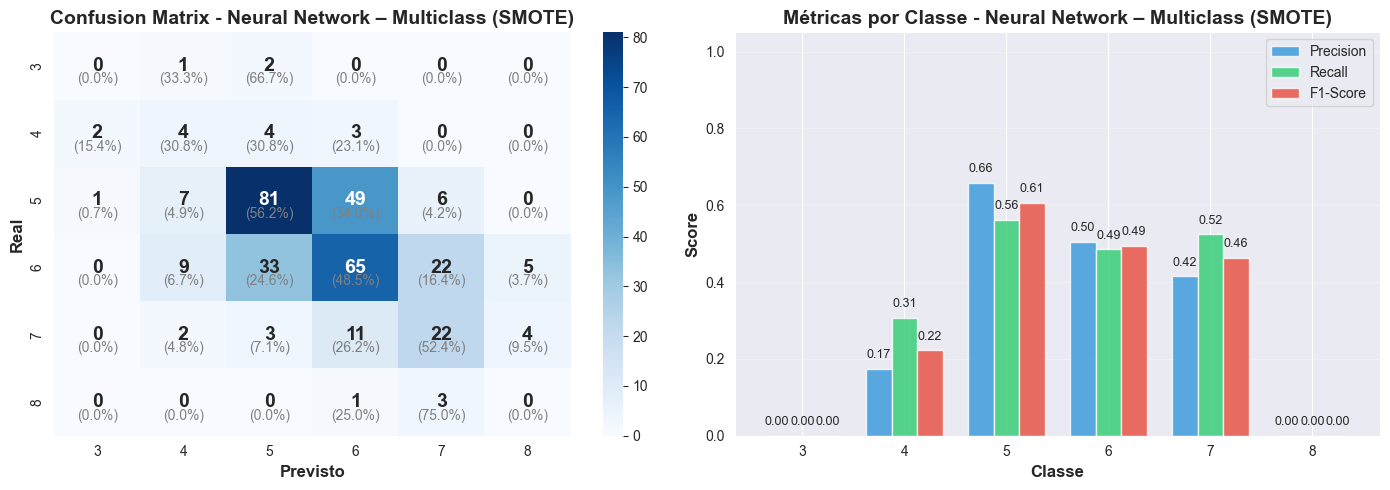


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 172 (50.59%)
   Erros: 168 (49.41%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 9/13 (69.2% de erro)
      Classe 5: 63/144 (43.8% de erro)
      Classe 6: 69/134 (51.5% de erro)
      Classe 7: 20/42 (47.6% de erro)
      Classe 8: 4/4 (100.0% de erro)



{'accuracy': 0.5058823529411764,
 'precision': 0.5354219999029779,
 'recall': 0.5058823529411764,
 'f1_score': 0.5174942600869327,
 'roc_auc': None,
 'confusion_matrix': array([[ 0,  1,  2,  0,  0,  0],
        [ 2,  4,  4,  3,  0,  0],
        [ 1,  7, 81, 49,  6,  0],
        [ 0,  9, 33, 65, 22,  5],
        [ 0,  2,  3, 11, 22,  4],
        [ 0,  0,  0,  1,  3,  0]]),
 'precision_per_class': array([0.        , 0.17391304, 0.65853659, 0.50387597, 0.41509434,
        0.        ]),
 'recall_per_class': array([0.        , 0.30769231, 0.5625    , 0.48507463, 0.52380952,
        0.        ]),
 'f1_per_class': array([0.        , 0.22222222, 0.60674157, 0.49429658, 0.46315789,
        0.        ]),
 'num_erros': np.int64(168),
 'total': 340}

In [166]:
avaliar_modelo(
    modelo=nn_multi,
    X_test=X_test_m_scaled,
    y_test=y_test_m,
    nome_modelo="Neural Network – Multiclass (SMOTE)"
)

## 15.7.2 random forest avaliaçao



 AVALIAÇÃO COMPLETA: Random Forest – Normalizada (SMOTE)

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.4765 (47.65%)
   Precision: 0.5628 (56.28%)
   Recall:    0.4765 (47.65%)
   F1-Score:  0.4827 (48.27%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3         
4          0.1957       0.6923       0.3051       13        
5          0.6549       0.6458       0.6503       144       
6          0.6034       0.2612       0.3646       134       
7          0.3247       0.5952       0.4202       42        
8          0.0000       0.0000       0.0000       4         
--------------------------------------------------------------------------------

 CLASSIF

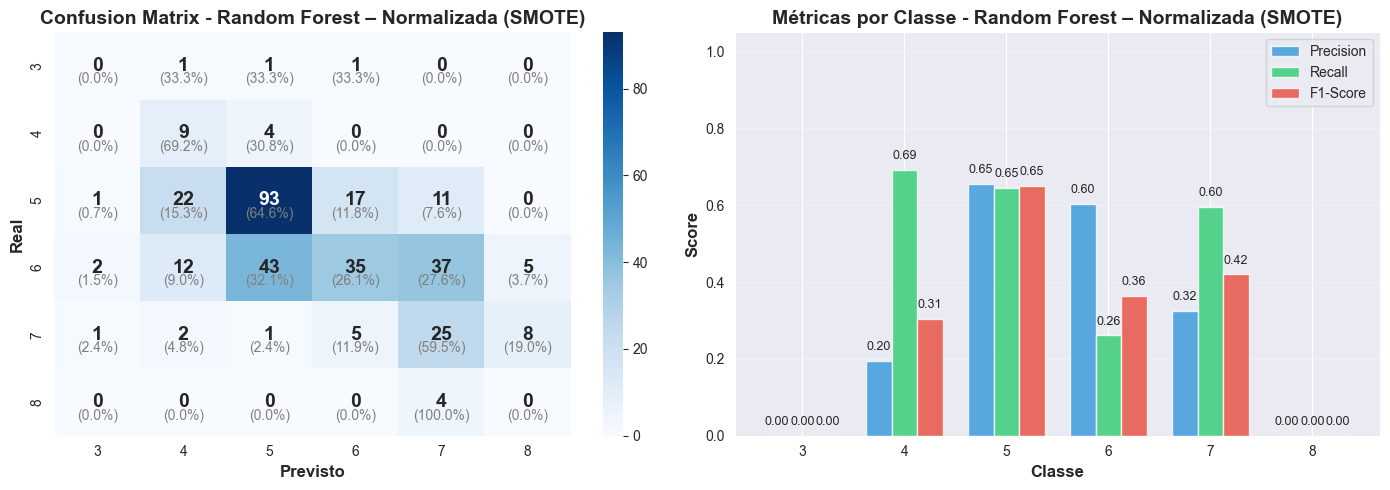


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 162 (47.65%)
   Erros: 178 (52.35%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 4/13 (30.8% de erro)
      Classe 5: 51/144 (35.4% de erro)
      Classe 6: 99/134 (73.9% de erro)
      Classe 7: 17/42 (40.5% de erro)
      Classe 8: 4/4 (100.0% de erro)



{'accuracy': 0.4764705882352941,
 'precision': 0.5627993235814117,
 'recall': 0.4764705882352941,
 'f1_score': 0.4826990495160617,
 'roc_auc': None,
 'confusion_matrix': array([[ 0,  1,  1,  1,  0,  0],
        [ 0,  9,  4,  0,  0,  0],
        [ 1, 22, 93, 17, 11,  0],
        [ 2, 12, 43, 35, 37,  5],
        [ 1,  2,  1,  5, 25,  8],
        [ 0,  0,  0,  0,  4,  0]]),
 'precision_per_class': array([0.        , 0.19565217, 0.65492958, 0.60344828, 0.32467532,
        0.        ]),
 'recall_per_class': array([0.        , 0.69230769, 0.64583333, 0.26119403, 0.5952381 ,
        0.        ]),
 'f1_per_class': array([0.        , 0.30508475, 0.65034965, 0.36458333, 0.42016807,
        0.        ]),
 'num_erros': np.int64(178),
 'total': 340}

In [167]:
avaliar_modelo(
    modelo=rf_multi_norm,
    X_test=X_test_m_scaled,
    y_test=y_test_m,
    nome_modelo="Random Forest – Normalizada (SMOTE)"
)

## 15.7.3 SVM avaliaçao


 AVALIAÇÃO COMPLETA: SVM – Multiclass (SMOTE)

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.5088 (50.88%)
   Precision: 0.5823 (58.23%)
   Recall:    0.5088 (50.88%)
   F1-Score:  0.5289 (52.89%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3         
4          0.1739       0.6154       0.2712       13        
5          0.6983       0.5625       0.6231       144       
6          0.5876       0.4254       0.4935       134       
7          0.3913       0.6429       0.4865       42        
8          0.0000       0.0000       0.0000       4         
--------------------------------------------------------------------------------

 CLASSIFICATION REP

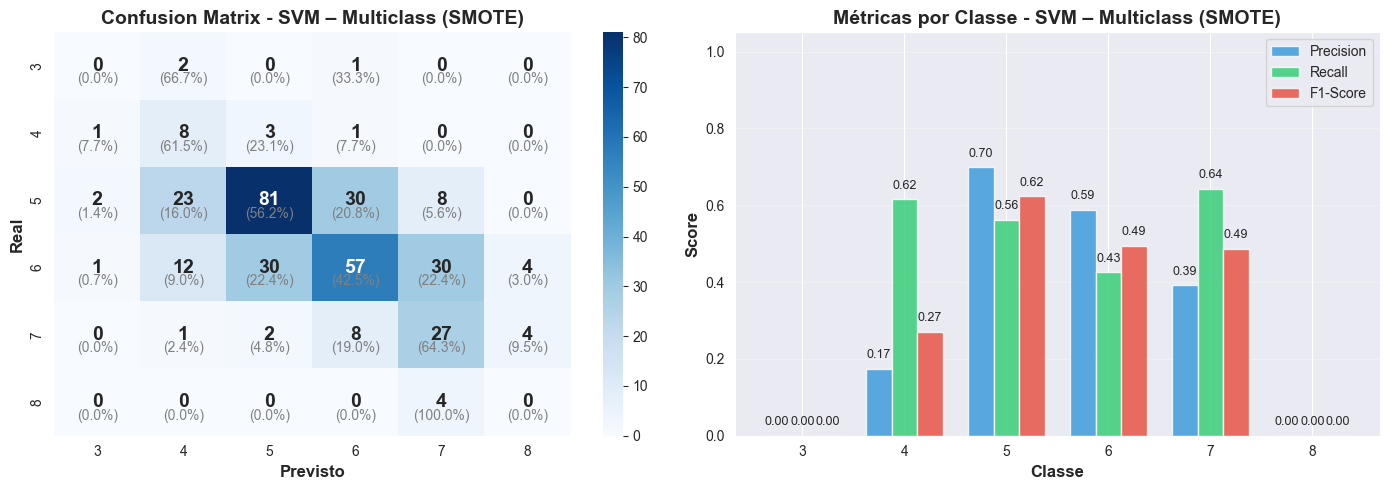


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 173 (50.88%)
   Erros: 167 (49.12%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 5/13 (38.5% de erro)
      Classe 5: 63/144 (43.8% de erro)
      Classe 6: 77/134 (57.5% de erro)
      Classe 7: 15/42 (35.7% de erro)
      Classe 8: 4/4 (100.0% de erro)



{'accuracy': 0.5088235294117647,
 'precision': 0.5823224833914152,
 'recall': 0.5088235294117647,
 'f1_score': 0.5288553035711561,
 'roc_auc': None,
 'confusion_matrix': array([[ 0,  2,  0,  1,  0,  0],
        [ 1,  8,  3,  1,  0,  0],
        [ 2, 23, 81, 30,  8,  0],
        [ 1, 12, 30, 57, 30,  4],
        [ 0,  1,  2,  8, 27,  4],
        [ 0,  0,  0,  0,  4,  0]]),
 'precision_per_class': array([0.        , 0.17391304, 0.69827586, 0.58762887, 0.39130435,
        0.        ]),
 'recall_per_class': array([0.        , 0.61538462, 0.5625    , 0.42537313, 0.64285714,
        0.        ]),
 'f1_per_class': array([0.        , 0.27118644, 0.62307692, 0.49350649, 0.48648649,
        0.        ]),
 'num_erros': np.int64(167),
 'total': 340}

In [168]:

avaliar_modelo(
    modelo=svm_multi,
    X_test=X_test_m_scaled,
    y_test=y_test_m,
    nome_modelo="SVM – Multiclass (SMOTE)"
)


# 16. Multiclasse com Remoção de Features

## 16.1 Dataset Reduzido

In [169]:
# Remover features fracas (as mesmas da binária)
features_to_drop = ['citric acid', 'chlorides', 'free sulfur dioxide']

wine_multi_red = wine_multi.drop(columns=features_to_drop)

# Separar X e y
X_multi_red = wine_multi_red.drop(columns=['quality'])
y_multi_red = wine_multi['quality']

wine_multi_red.head()


,fixed acidity,volatile acidity,residual sugar,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,1.9,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,2.6,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,2.3,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,1.9,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,1.8,40.0,0.9978,3.51,0.56,9.4,5


## 16.2 SMOTE + Normalização

In [170]:
# Train/Test Split
X_train_mr, X_test_mr, y_train_mr, y_test_mr = train_test_split(
    X_multi_red, y_multi_red,
    test_size=0.25,
    random_state=42,
    stratify=y_multi_red
)

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_mr_res, y_train_mr_res = smote.fit_resample(X_train_mr, y_train_mr)

# Normalização
scaler_mr = StandardScaler()
X_train_mr_scaled = scaler_mr.fit_transform(X_train_mr_res)
X_test_mr_scaled = scaler_mr.transform(X_test_mr)


## 16.3 Avaliação NN, RF e SVM

=== Teste Multiclass (sem 3 features fracas) ===

 AVALIAÇÃO COMPLETA: NN Multiclass — Reduced

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.5147 (51.47%)
   Precision: 0.5624 (56.24%)
   Recall:    0.5147 (51.47%)
   F1-Score:  0.5338 (53.38%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3         
4          0.1667       0.3077       0.2162       13        
5          0.7311       0.6042       0.6616       144       
6          0.5280       0.4925       0.5097       134       
7          0.3103       0.4286       0.3600       42        
8          0.0000       0.0000       0.0000       4         
-----------------------------------------------------

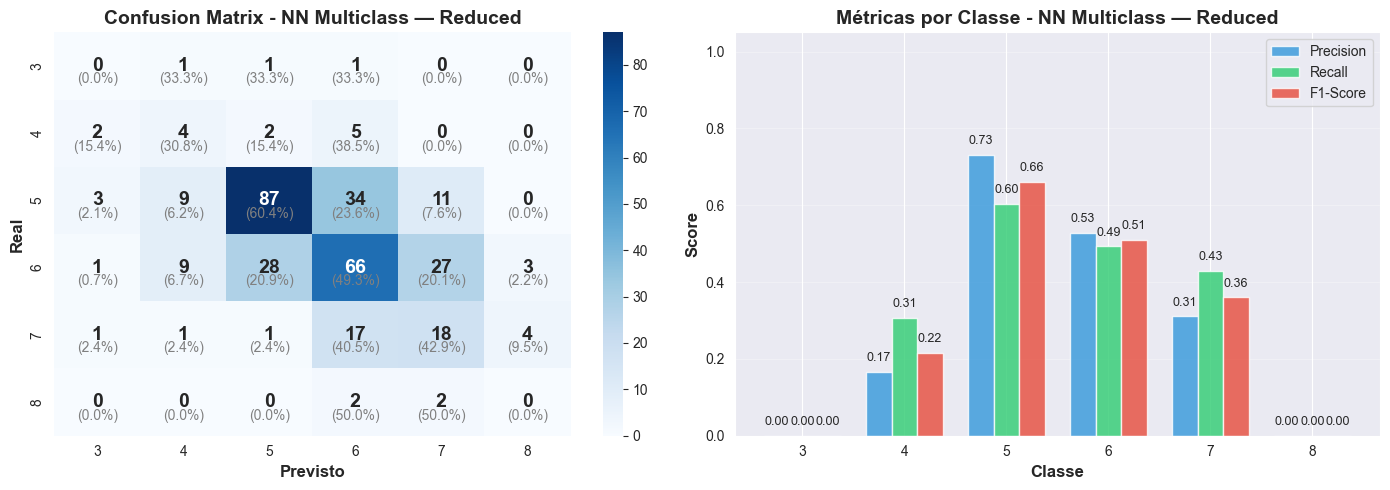


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 175 (51.47%)
   Erros: 165 (48.53%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 9/13 (69.2% de erro)
      Classe 5: 57/144 (39.6% de erro)
      Classe 6: 68/134 (50.7% de erro)
      Classe 7: 24/42 (57.1% de erro)
      Classe 8: 4/4 (100.0% de erro)


 AVALIAÇÃO COMPLETA: RF Multiclass — Reduced

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.4265 (42.65%)
   Precision: 0.4939 (49.39%)
   Recall:    0.4265 (42.65%)
   F1-Score:  0.4282 (42.82%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       

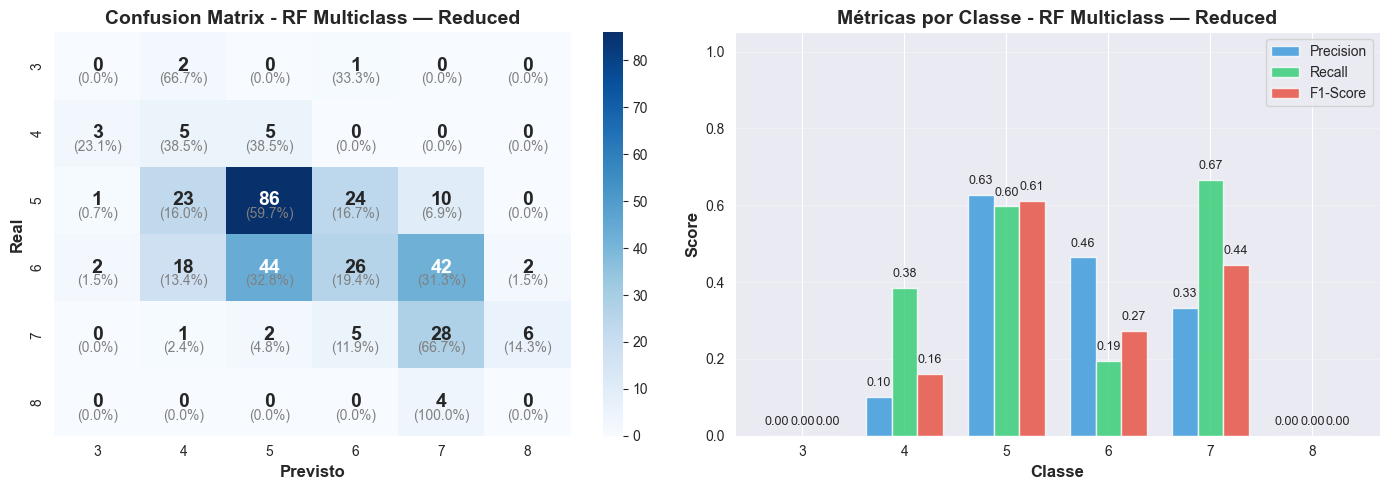


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 145 (42.65%)
   Erros: 195 (57.35%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 8/13 (61.5% de erro)
      Classe 5: 58/144 (40.3% de erro)
      Classe 6: 108/134 (80.6% de erro)
      Classe 7: 14/42 (33.3% de erro)
      Classe 8: 4/4 (100.0% de erro)


 AVALIAÇÃO COMPLETA: SVM Multiclass — Reduced

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.4912 (49.12%)
   Precision: 0.5758 (57.58%)
   Recall:    0.4912 (49.12%)
   F1-Score:  0.5158 (51.58%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000     

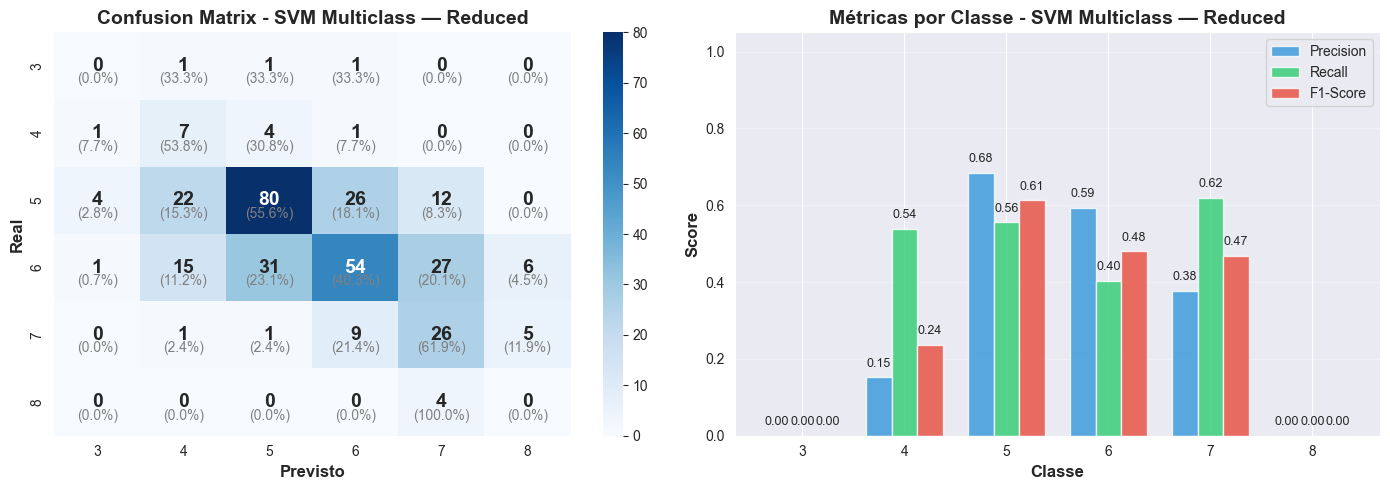


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 167 (49.12%)
   Erros: 173 (50.88%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 6/13 (46.2% de erro)
      Classe 5: 64/144 (44.4% de erro)
      Classe 6: 80/134 (59.7% de erro)
      Classe 7: 16/42 (38.1% de erro)
      Classe 8: 4/4 (100.0% de erro)



{'accuracy': 0.49117647058823527,
 'precision': 0.5758304994238499,
 'recall': 0.49117647058823527,
 'f1_score': 0.5157537750216267,
 'roc_auc': None,
 'confusion_matrix': array([[ 0,  1,  1,  1,  0,  0],
        [ 1,  7,  4,  1,  0,  0],
        [ 4, 22, 80, 26, 12,  0],
        [ 1, 15, 31, 54, 27,  6],
        [ 0,  1,  1,  9, 26,  5],
        [ 0,  0,  0,  0,  4,  0]]),
 'precision_per_class': array([0.        , 0.15217391, 0.68376068, 0.59340659, 0.37681159,
        0.        ]),
 'recall_per_class': array([0.        , 0.53846154, 0.55555556, 0.40298507, 0.61904762,
        0.        ]),
 'f1_per_class': array([0.        , 0.23728814, 0.61302682, 0.48      , 0.46846847,
        0.        ]),
 'num_erros': np.int64(173),
 'total': 340}

In [171]:
print("=== Teste Multiclass (sem 3 features fracas) ===")

# NN
nn_mr = MLPClassifier(hidden_layer_sizes=(64,),
    activation='tanh',
    solver='sgd',
    alpha=0.05,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=42)
nn_mr.fit(X_train_mr_scaled, y_train_mr_res)

avaliar_modelo(nn_mr, X_test_mr_scaled, y_test_mr, "NN Multiclass — Reduced")

# RF
rf_mr = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42  )
rf_mr.fit(X_train_mr_scaled, y_train_mr_res)

avaliar_modelo(rf_mr, X_test_mr_scaled, y_test_mr, "RF Multiclass — Reduced")

# SVM
svm_mr = SVC(kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,
    probability=True,
    random_state=42)
svm_mr.fit(X_train_mr_scaled, y_train_mr_res)

avaliar_modelo(svm_mr, X_test_mr_scaled, y_test_mr, "SVM Multiclass — Reduced")


# 17. Multiclasse com Feature Engineering

## 17.1 Feature Engineering Multiclasse

In [172]:
df_mfe = wine_multi.copy()

# ENGINEERED FEATURES — MESMO QUE NA BINÁRIA
df_mfe['SO2_ratio'] = df_mfe['free sulfur dioxide'] / (df_mfe['total sulfur dioxide'] + 1e-6)
df_mfe['acidity_index'] = df_mfe['fixed acidity'] / (df_mfe['pH'] + 1e-6)
df_mfe['alc_density_diff'] = df_mfe['alcohol'] - df_mfe['density']
df_mfe['total_acidity'] = df_mfe['fixed acidity'] + df_mfe['volatile acidity'] + df_mfe['citric acid']
df_mfe['sulphates_per_alc'] = df_mfe['sulphates'] / (df_mfe['alcohol'] + 1e-6)

for col in ['residual sugar', 'chlorides', 'sulphates', 'total sulfur dioxide']:
    df_mfe[f'log_{col.replace(" ", "_")}'] = np.log1p(df_mfe[col])

X_mfe = df_mfe.drop(columns=['quality'])
y_mfe = df_mfe['quality']


## 17.2 SMOTE + Normalização

In [173]:
X_train_mfe, X_test_mfe, y_train_mfe, y_test_mfe = train_test_split(
    X_mfe, y_mfe, test_size=0.25, random_state=42, stratify=y_mfe
)

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_mfe_res, y_train_mfe_res = smote.fit_resample(X_train_mfe, y_train_mfe)

scaler_mfe = StandardScaler()
X_train_mfe_scaled = scaler_mfe.fit_transform(X_train_mfe_res)
X_test_mfe_scaled = scaler_mfe.transform(X_test_mfe)


## 17.3 Avaliação NN, RF e SVM

=== Multiclass Feature Engineering ===

 AVALIAÇÃO COMPLETA: NN — FE

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.5147 (51.47%)
   Precision: 0.5382 (53.82%)
   Recall:    0.5147 (51.47%)
   F1-Score:  0.5237 (52.37%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3         
4          0.1176       0.1538       0.1333       13        
5          0.6500       0.5417       0.5909       144       
6          0.5390       0.5672       0.5527       134       
7          0.3725       0.4524       0.4086       42        
8          0.0000       0.0000       0.0000       4         
-------------------------------------------------------------------------------

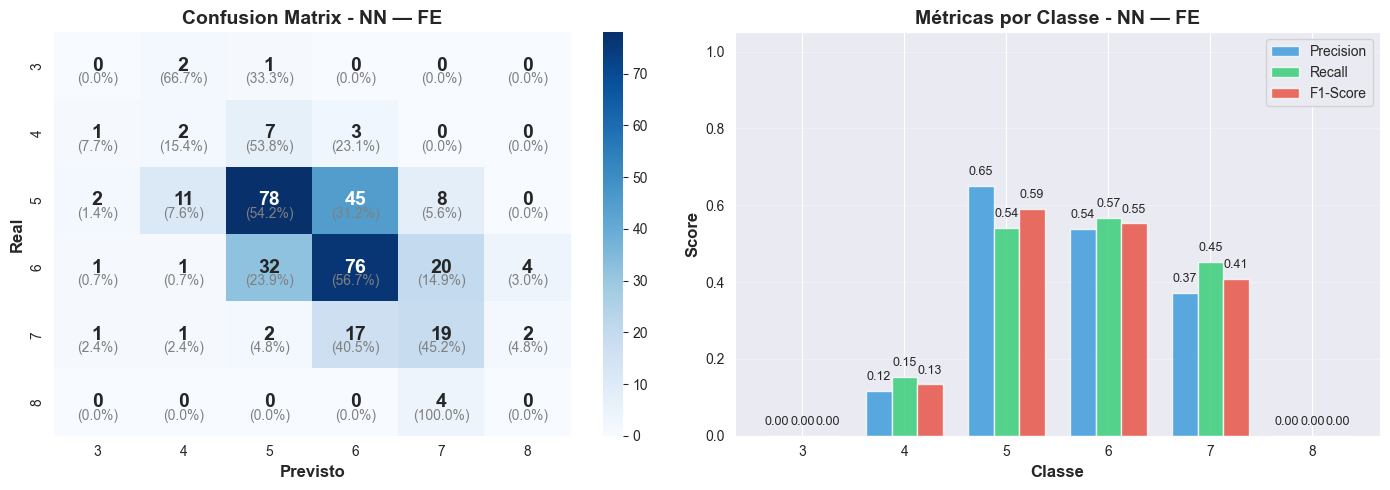


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 175 (51.47%)
   Erros: 165 (48.53%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 11/13 (84.6% de erro)
      Classe 5: 66/144 (45.8% de erro)
      Classe 6: 58/134 (43.3% de erro)
      Classe 7: 23/42 (54.8% de erro)
      Classe 8: 4/4 (100.0% de erro)


 AVALIAÇÃO COMPLETA: RF — FE

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.4353 (43.53%)
   Precision: 0.5445 (54.45%)
   Recall:    0.4353 (43.53%)
   F1-Score:  0.4497 (44.97%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3 

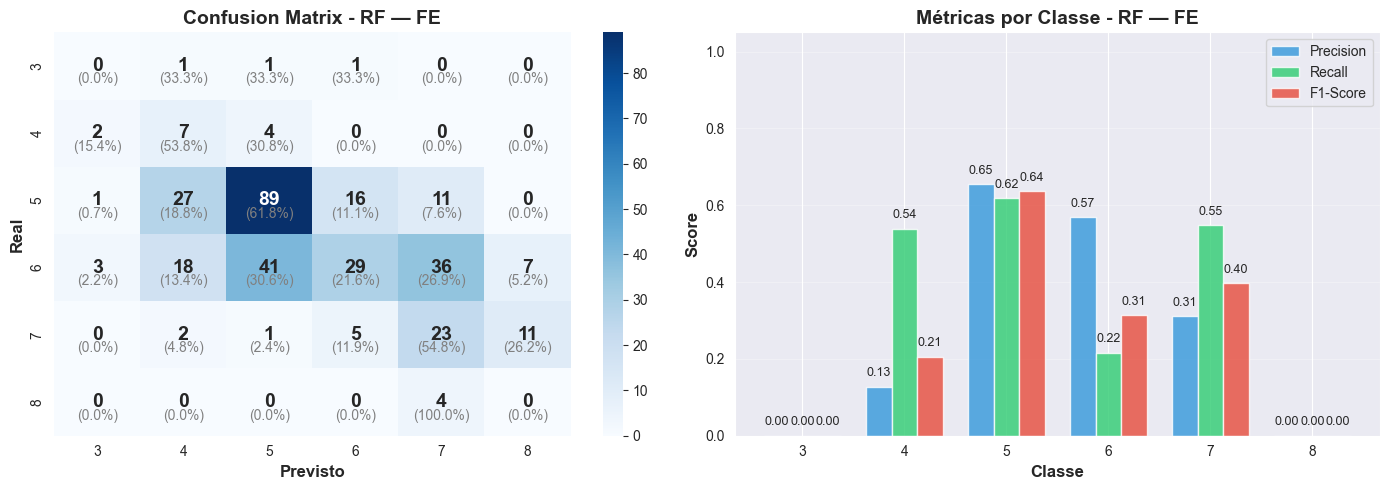


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 148 (43.53%)
   Erros: 192 (56.47%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 6/13 (46.2% de erro)
      Classe 5: 55/144 (38.2% de erro)
      Classe 6: 105/134 (78.4% de erro)
      Classe 7: 19/42 (45.2% de erro)
      Classe 8: 4/4 (100.0% de erro)


 AVALIAÇÃO COMPLETA: SVM — FE

 MÉTRICAS GLOBAIS (Weighted Average):
--------------------------------------------------------------------------------
   Accuracy:  0.4971 (49.71%)
   Precision: 0.5661 (56.61%)
   Recall:    0.4971 (49.71%)
   F1-Score:  0.5170 (51.70%)

 MÉTRICAS POR CLASSE:
--------------------------------------------------------------------------------
Classe     Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
3          0.0000       0.0000       0.0000       3

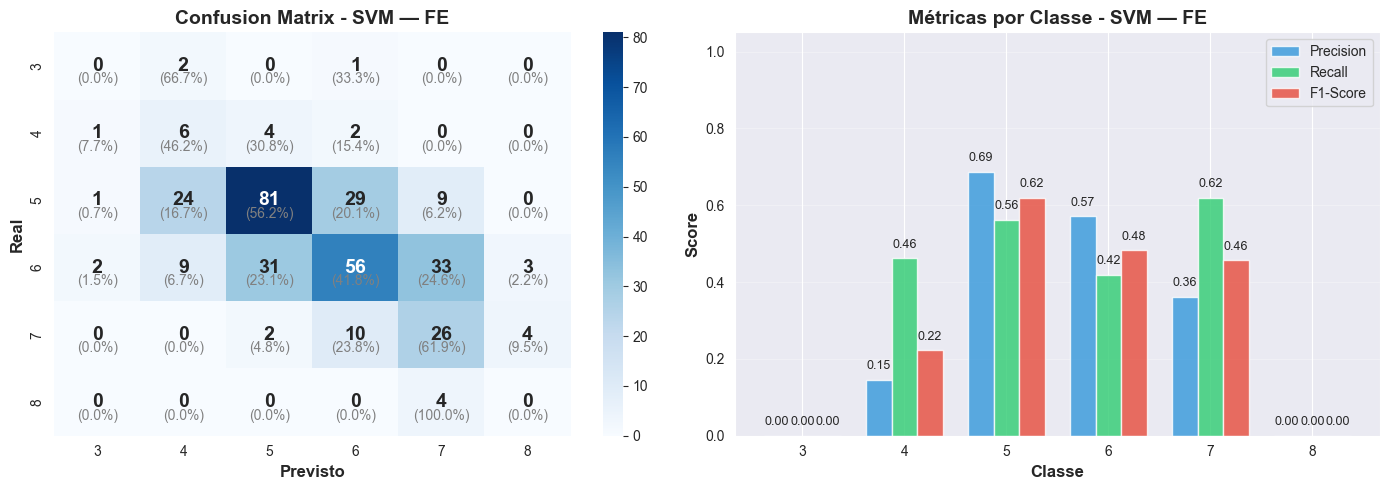


 ANÁLISE DE ERROS:
--------------------------------------------------------------------------------
   Total de previsões: 340
   Acertos: 169 (49.71%)
   Erros: 171 (50.29%)

   Distribuição de Erros:
      Classe 3: 3/3 (100.0% de erro)
      Classe 4: 7/13 (53.8% de erro)
      Classe 5: 63/144 (43.8% de erro)
      Classe 6: 78/134 (58.2% de erro)
      Classe 7: 16/42 (38.1% de erro)
      Classe 8: 4/4 (100.0% de erro)



{'accuracy': 0.4970588235294118,
 'precision': 0.5661411526164827,
 'recall': 0.4970588235294118,
 'f1_score': 0.5169841374619885,
 'roc_auc': None,
 'confusion_matrix': array([[ 0,  2,  0,  1,  0,  0],
        [ 1,  6,  4,  2,  0,  0],
        [ 1, 24, 81, 29,  9,  0],
        [ 2,  9, 31, 56, 33,  3],
        [ 0,  0,  2, 10, 26,  4],
        [ 0,  0,  0,  0,  4,  0]]),
 'precision_per_class': array([0.        , 0.14634146, 0.68644068, 0.57142857, 0.36111111,
        0.        ]),
 'recall_per_class': array([0.        , 0.46153846, 0.5625    , 0.41791045, 0.61904762,
        0.        ]),
 'f1_per_class': array([0.        , 0.22222222, 0.61832061, 0.48275862, 0.45614035,
        0.        ]),
 'num_erros': np.int64(171),
 'total': 340}

In [174]:
print("=== Multiclass Feature Engineering ===")

# NN
nn_mfe = MLPClassifier(hidden_layer_sizes=(64,),
    activation='tanh',
    solver='sgd',
    alpha=0.05,
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=42)
nn_mfe.fit(X_train_mfe_scaled, y_train_mfe_res)

avaliar_modelo(nn_mfe, X_test_mfe_scaled, y_test_mfe, "NN — FE")

# RF
rf_mfe = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42  )
rf_mfe.fit(X_train_mfe_scaled, y_train_mfe_res)

avaliar_modelo(rf_mfe, X_test_mfe_scaled, y_test_mfe, "RF — FE")

# SVM
svm_mfe = SVC(kernel='rbf',
    C=1,
    gamma='scale',
    degree=2,          # incluído para corresponder ao modelo escolhido (é ignorado pelo RBF)
    probability=True,
    random_state=42)
svm_mfe.fit(X_train_mfe_scaled, y_train_mfe_res)

avaliar_modelo(svm_mfe, X_test_mfe_scaled, y_test_mfe, "SVM — FE")


# 18. Multiclasse com Feature Engineering com remoçao de features

## 18.1 Ranking de features

In [175]:
## Ranking de Features (MI + RF + PI)

X_mfe = df_mfe.drop(columns=['quality'])
y_mfe = df_mfe['quality']

# Mutual Information
mi_vals = mutual_info_classif(X_mfe, y_mfe, random_state=42)
mi_df = pd.DataFrame({'Feature': X_mfe.columns, 'MI': mi_vals})

# Random Forest importance
rf_temp = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42 )
rf_temp.fit(X_mfe, y_mfe)
rf_df = pd.DataFrame({'Feature': X_mfe.columns, 'RF': rf_temp.feature_importances_})

# Permutation Importance (usa uma pequena RF para ser rápido)
perm = permutation_importance(
    rf_temp, X_mfe, y_mfe, n_repeats=5, random_state=42
)
pi_df = pd.DataFrame({'Feature': X_mfe.columns, 'PI': perm.importances_mean})

# Combinar rankings
rank_df = mi_df.merge(rf_df, on='Feature').merge(pi_df, on='Feature')

# Normalizar
for col in ['MI', 'RF', 'PI']:
    rank_df[col] = (rank_df[col] - rank_df[col].min()) / (rank_df[col].max() - rank_df[col].min())

rank_df['Score'] = rank_df['MI'] + rank_df['RF'] + rank_df['PI']

# Ranking final
rank_df = rank_df.sort_values('Score', ascending=False)
ranking_multiclass = list(rank_df['Feature'])

ranking_multiclass[:15]  # mostrar top 15


['alc_density_diff',
 'alcohol',
 'volatile acidity',
 'sulphates',
 'log_sulphates',
 'log_total_sulfur_dioxide',
 'SO2_ratio',
 'total sulfur dioxide',
 'sulphates_per_alc',
 'density',
 'free sulfur dioxide',
 'citric acid',
 'chlorides',
 'fixed acidity',
 'acidity_index']

## 18.2 Testar Top K features (8, 10, 12) NN, RF, SVM

In [176]:
def testar_top_k(df, target, ranking, topks=[8, 10, 12], n_runs=30):
    resultados = []

    # ---------- Função de estatísticas (igual ao teu exemplo) ----------
    def estatisticas(v):
        v = np.array(v)
        mean = np.mean(v)
        std = np.std(v)
        se = std / np.sqrt(len(v))
        mediana = np.median(v)
        minimo = np.min(v)
        maximo = np.max(v)
        q1 = np.percentile(v, 25)
        q3 = np.percentile(v, 75)
        iqr = q3 - q1
        cv = (std / mean) * 100
        ic_low = mean - 1.96 * se
        ic_up = mean + 1.96 * se
        return mean, std, se, mediana, minimo, maximo, q1, q3, iqr, cv, ic_low, ic_up

    for k in topks:
        print(f"\n======================\n   TESTAR TOP {k}\n======================")

        # Selecionar features
        selected = ranking[:k]
        X = df[selected]
        y = df[target]

        # Train/Test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        # Normalização
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # ======================================================
        # =============== RANDOM FOREST — ENSEMBLE 30 ==========
        # ======================================================
        print(f"\n---- RANDOM FOREST (Top {k}) ----")
        rf_accs, rf_precs, rf_recs, rf_f1s = [], [], [], []

        for i in range(n_runs):
            rf = RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                min_samples_split=5,
                min_samples_leaf=1,
                bootstrap=True,
                random_state=42 + i
            )
            rf.fit(X_train_scaled, y_train)
            pred = rf.predict(X_test_scaled)

            rf_accs.append(accuracy_score(y_test, pred))
            rf_precs.append(precision_score(y_test, pred, average='weighted', zero_division=0))
            rf_recs.append(recall_score(y_test, pred, average='weighted', zero_division=0))
            rf_f1s.append(f1_score(y_test, pred, average='weighted', zero_division=0))

            print(f"RF Run {i+1:02d}/{n_runs} → Acc={rf_accs[-1]:.4f}")

        # Estatísticas RF
        mean, std, se, mediana, minimo, maximo, q1, q3, iqr, cv, ic_low, ic_up = estatisticas(rf_accs)

        print("\n==========================================")
        print("     ESTATÍSTICAS DO ENSEMBLE (30 RF)")
        print("==========================================")
        print(f"   Média (μ):               {mean:.4f}")
        print(f"   Desvio Padrão (σ):       {std:.4f}")
        print(f"   Standard Error (SE):     {se:.4f}")
        print(f"   Mediana:                 {mediana:.4f}")
        print(f"   Mínimo:                  {minimo:.4f}")
        print(f"   Máximo:                  {maximo:.4f}")
        print(f"   Quartil 1 (Q1):          {q1:.4f}")
        print(f"   Quartil 3 (Q3):          {q3:.4f}")
        print(f"   IQR (Q3 − Q1):           {iqr:.4f}")
        print(f"   Coef. Variação (CV):     {cv:.2f}%")
        print("\nINTERVALO DE CONFIANÇA (95%):")
        print(f"   [{ic_low:.4f}, {ic_up:.4f}]")

        # Inserir média RF na tabela final (como antes)
        resultados.append([
            "RandomForest", k,
            mean,
            np.mean(rf_precs),
            np.mean(rf_recs),
            np.mean(rf_f1s)
        ])

        # ======================================================
        # =============== NEURAL NETWORK — ENSEMBLE 30 =========
        # ======================================================
        print(f"\n---- NEURAL NETWORK (Top {k}) ----")
        nn_accs, nn_precs, nn_recs, nn_f1s = [], [], [], []

        for i in range(n_runs):
            nn = MLPClassifier(
                hidden_layer_sizes=(64,),
                activation='tanh',
                solver='sgd',
                alpha=0.05,
                learning_rate='constant',
                learning_rate_init=0.01,
                max_iter=2500,
                random_state=42 + i
            )
            nn.fit(X_train_scaled, y_train)
            pred = nn.predict(X_test_scaled)

            nn_accs.append(accuracy_score(y_test, pred))
            nn_precs.append(precision_score(y_test, pred, average='weighted', zero_division=0))
            nn_recs.append(recall_score(y_test, pred, average='weighted', zero_division=0))
            nn_f1s.append(f1_score(y_test, pred, average='weighted', zero_division=0))

            print(f"NN Run {i+1:02d}/{n_runs} → Acc={nn_accs[-1]:.4f}")

        mean, std, se, mediana, minimo, maximo, q1, q3, iqr, cv, ic_low, ic_up = estatisticas(nn_accs)

        print("\n==========================================")
        print("     ESTATÍSTICAS DO ENSEMBLE (30 NN)")
        print("==========================================")
        print(f"   Média (μ):               {mean:.4f}")
        print(f"   Desvio Padrão (σ):       {std:.4f}")
        print(f"   Standard Error (SE):     {se:.4f}")
        print(f"   Mediana:                 {mediana:.4f}")
        print(f"   Mínimo:                  {minimo:.4f}")
        print(f"   Máximo:                  {maximo:.4f}")
        print(f"   Q1:                      {q1:.4f}")
        print(f"   Q3:                      {q3:.4f}")
        print(f"   IQR:                     {iqr:.4f}")
        print(f"   CV:                      {cv:.2f}%")
        print("\nINTERVALO DE CONFIANÇA (95%):")
        print(f"   [{ic_low:.4f}, {ic_up:.4f}]")

        resultados.append([
            "NeuralNetwork", k,
            mean,
            np.mean(nn_precs),
            np.mean(nn_recs),
            np.mean(nn_f1s)
        ])

        # ======================================================
        # =================== SVM — 1 RUN ======================
        # ======================================================
        print(f"\n---- SVM (Top {k}) ----")

        svm = SVC(
            kernel='rbf',
            C=1,
            gamma='scale',
            degree=2,
            probability=True,
            random_state=42
        )
        svm.fit(X_train_scaled, y_train)
        pred = svm.predict(X_test_scaled)

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, pred, average='weighted', zero_division=0)

        print(f"SVM → Acc={acc:.4f} | F1={f1:.4f}")

        resultados.append([
            "SVM", k,
            acc, prec, rec, f1
        ])

    # =======================
    #   TABELA FINAL
    # =======================
    df_result = pd.DataFrame(resultados, columns=[
        "Modelo", "TopK", "Accuracy", "Precision", "Recall", "F1"
    ])

    order_modelos = ["RandomForest", "NeuralNetwork", "SVM"]
    df_result["Modelo"] = pd.Categorical(df_result["Modelo"], categories=order_modelos, ordered=True)
    df_result = df_result.sort_values(["Modelo", "TopK"]).reset_index(drop=True)

    return df_result


In [177]:
df_multi_topk = testar_top_k(
    df=df_mfe,
    target="quality",
    ranking=ranking_completo
)

df_multi_topk



   TESTAR TOP 8

---- RANDOM FOREST (Top 8) ----
RF Run 01/30 → Acc=0.5912
RF Run 02/30 → Acc=0.5765
RF Run 03/30 → Acc=0.5735
RF Run 04/30 → Acc=0.5765
RF Run 05/30 → Acc=0.5794
RF Run 06/30 → Acc=0.5824
RF Run 07/30 → Acc=0.5765
RF Run 08/30 → Acc=0.5706
RF Run 09/30 → Acc=0.5735
RF Run 10/30 → Acc=0.5706
RF Run 11/30 → Acc=0.5706
RF Run 12/30 → Acc=0.5765
RF Run 13/30 → Acc=0.5824
RF Run 14/30 → Acc=0.5765
RF Run 15/30 → Acc=0.5824
RF Run 16/30 → Acc=0.5735
RF Run 17/30 → Acc=0.5765
RF Run 18/30 → Acc=0.5706
RF Run 19/30 → Acc=0.5647
RF Run 20/30 → Acc=0.5882
RF Run 21/30 → Acc=0.5794
RF Run 22/30 → Acc=0.5735
RF Run 23/30 → Acc=0.5824
RF Run 24/30 → Acc=0.5765
RF Run 25/30 → Acc=0.5794
RF Run 26/30 → Acc=0.5647
RF Run 27/30 → Acc=0.5765
RF Run 28/30 → Acc=0.5912
RF Run 29/30 → Acc=0.5735
RF Run 30/30 → Acc=0.5794

     ESTATÍSTICAS DO ENSEMBLE (30 RF)
   Média (μ):               0.5770
   Desvio Padrão (σ):       0.0063
   Standard Error (SE):     0.0012
   Mediana:               

,Modelo,TopK,Accuracy,Precision,Recall,F1
0,RandomForest,8,0.576961,0.548797,0.576961,0.552657
1,RandomForest,10,0.568235,0.542706,0.568235,0.545363
2,RandomForest,12,0.567843,0.540127,0.567843,0.541575
3,NeuralNetwork,8,0.575000,0.542835,0.575000,0.555779
4,NeuralNetwork,10,0.563235,0.530774,0.563235,0.544860
5,NeuralNetwork,12,0.569216,0.547747,0.569216,0.554798
6,SVM,8,0.555882,0.524665,0.555882,0.532115
7,SVM,10,0.561765,0.529815,0.561765,0.538488
8,SVM,12,0.576471,0.540941,0.576471,0.554230
